# Final Checkup Forecasting PM2.5 AirSafe

Notebook ini digunakan sebagai tahap **final checkup** untuk menguji pipeline forecasting PM2.5 secara end-to-end pada periode demo terbaru.

Rentang demo yang digunakan adalah:

| Komponen | Nilai |
|---|---|
| Tanggal mulai demo | `2026-04-22` |
| Tanggal akhir demo | `2026-04-28` |
| Jumlah hari | 7 hari |
| Resolusi data | Per jam |
| Jumlah stasiun | 5 stasiun |

Notebook ini menjalankan seluruh alur dari awal sampai akhir, yaitu:

1. Scraping data SPKU terbaru.
2. Mengambil data cuaca Open-Meteo.
3. Menggabungkan data demo dengan historical master.
4. Membuat ulang fitur untuk H6, H12, dan H24.
5. Melatih ulang LightGBM pada data historis.
6. Menguji model pada periode demo.
7. Menghitung metrik final checkup.
8. Membuat grafik evaluasi.
9. Menghasilkan SHAP explanation.
10. Membentuk prompt package untuk LLM rekomendasi AirSafe.

Dengan demikian, notebook ini bukan sekadar notebook modeling, tetapi menjadi simulasi pipeline operasional untuk mengecek apakah sistem forecasting, explainability, dan prompt generation sudah berjalan utuh.

## Mengambil Data SPKU Demo 7 Hari dari Lima Stasiun Jakarta

Cell ini melakukan scraping data SPKU/ISPU untuk lima stasiun kualitas udara DKI Jakarta pada periode demo `2026-04-22` sampai `2026-04-28`.

Stasiun yang digunakan adalah:

| Station ID | Slug | Nama Stasiun |
|---:|---|---|
| 4 | `dki1-bundaran-hi` | DKI1 Bundaran HI |
| 5 | `dki2-kelapa-gading` | DKI2 Kelapa Gading |
| 6 | `dki3-jagakarsa` | DKI3 Jagakarsa |
| 7 | `dki4-lubang-buaya` | DKI4 Lubang Buaya |
| 8 | `dki5-kebun-jeruk` | DKI5 Kebun Jeruk |

### Konfigurasi Scraping

Beberapa konfigurasi penting pada cell ini adalah:

| Parameter | Nilai | Fungsi |
|---|---:|---|
| `START_DATE` | `2026-04-22` | Tanggal awal scraping |
| `END_DATE` | `2026-04-28` | Tanggal akhir scraping |
| `MAX_WORKERS` | 3 | Jumlah proses paralel |
| `MAX_RETRIES` | 3 | Jumlah percobaan ulang jika request gagal |
| `TIMEOUT` | 40 | Batas waktu request |
| `DROP_ALL_NAN_ROWS` | `False` | Baris kosong tidak langsung dibuang |

Data polutan yang diambil adalah:

```text
pm10, pm25, so2, co, o3, no2, hc
```

### Folder Output

Cell ini menyimpan hasil scraping ke dalam folder utama:

```text
final_checkup/
```

Subfolder yang dibuat adalah:

| Folder | Fungsi |
|---|---|
| `final_checkup/raw_spku_20260422_20260428/` | Menyimpan file mentah SPKU per stasiun |
| `final_checkup/logs_spku_20260422_20260428/` | Menyimpan log scraping per stasiun |
| `final_checkup/master/` | Menyimpan master SPKU demo |

### Output Scraping

Setiap stasiun menghasilkan 168 baris data.

Angka ini berasal dari:

```text
7 hari × 24 jam = 168 baris per stasiun
```

Karena ada 5 stasiun, total master demo menjadi:

```text
168 × 5 = 840 baris
```

Output utama yang disimpan adalah:

```text
final_checkup/master/spku_demo_5stations_2026-04-22_2026-04-28.csv
final_checkup/master/spku_demo_5stations_2026-04-22_2026-04-28.parquet
```

Cell ini menjadi tahap awal final checkup karena memastikan data SPKU terbaru berhasil diambil sebelum masuk ke proses merge, feature engineering, dan evaluasi model.

In [1]:
# =========================================================
# SCRAPER SPKU 5 STASIUN
# RANGE DEMO: 2026-04-22 s.d. 2026-04-28
# Semua output masuk ke folder:
#   final_checkup/
# =========================================================

import re
import time
import random
from io import StringIO
from pathlib import Path
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed

import requests
import pandas as pd
from bs4 import BeautifulSoup
from tqdm.auto import tqdm

# -----------------------------
# CONFIG
# -----------------------------
START_DATE = "2026-04-22"
END_DATE   = "2026-04-28"

MAX_WORKERS = 3
MAX_RETRIES = 3
TIMEOUT = 40
BACKOFF_BASE = 2.0

DROP_ALL_NAN_ROWS = False

# =============================
# FOLDER OUTPUT FINAL CHECKUP
# =============================
FINAL_CHECKUP_DIR = Path("final_checkup")
RAW_DIR = FINAL_CHECKUP_DIR / "raw_spku_20260422_20260428"
LOG_DIR = FINAL_CHECKUP_DIR / "logs_spku_20260422_20260428"
MASTER_DIR = FINAL_CHECKUP_DIR / "master"

FINAL_CHECKUP_DIR.mkdir(exist_ok=True)
RAW_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(exist_ok=True)
MASTER_DIR.mkdir(exist_ok=True)

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "id-ID,id;q=0.9,en-US;q=0.8,en;q=0.7",
}

STATIONS = [
    {"station_id": 4, "slug": "dki1-bundaran-hi",   "station_name": "DKI1 Bundaran HI"},
    {"station_id": 5, "slug": "dki2-kelapa-gading", "station_name": "DKI2 Kelapa Gading"},
    {"station_id": 6, "slug": "dki3-jagakarsa",     "station_name": "DKI3 Jagakarsa"},
    {"station_id": 7, "slug": "dki4-lubang-buaya",  "station_name": "DKI4 Lubang Buaya"},
    {"station_id": 8, "slug": "dki5-kebun-jeruk",   "station_name": "DKI5 Kebun Jeruk"},
]

POLLUTANT_COLS = ["pm10", "pm25", "so2", "co", "o3", "no2", "hc"]


# -----------------------------
# HELPERS
# -----------------------------
def daterange(start_dt, end_dt):
    cur = start_dt
    while cur <= end_dt:
        yield cur
        cur += timedelta(days=1)

def build_url(station_id, slug, dt):
    return f"https://rendahemisi.jakarta.go.id/ispu-detail/{station_id}/{slug}/{dt.strftime('%d-%m-%Y')}"

def norm_col(c):
    c = str(c).strip().lower()
    c = c.replace(" ", "").replace(".", "")
    return c

def extract_regex(text, pattern, flags=re.S):
    m = re.search(pattern, text, flags)
    return m.group(1).strip() if m else None

def parse_location_and_update(page_text):
    last_update = extract_regex(
        page_text,
        r"Terakhir Update:\s*(.*?)\s*(?:Lokasi:|Sumber:|Keterangan:|$)"
    )
    lokasi = extract_regex(
        page_text,
        r"Lokasi:\s*(.*?)\s*(?:Sumber:|Keterangan:|$)"
    )
    return lokasi, last_update

def parse_hourly_table(html, station, dt, url):
    soup = BeautifulSoup(html, "html.parser")
    page_text = soup.get_text("\n", strip=True)

    try:
        tables = pd.read_html(StringIO(html))
    except Exception:
        return None

    target = None
    for tbl in tables:
        cols = [norm_col(c) for c in tbl.columns]
        if "waktu" in cols:
            target = tbl.copy()
            target.columns = cols
            break

    if target is None:
        return None

    rename_map = {
        "waktu": "hour",
        "pm10": "pm10",
        "pm25": "pm25",
        "so2": "so2",
        "co": "co",
        "o3": "o3",
        "no2": "no2",
        "hc": "hc",
        "kategori": "kategori",
    }
    target = target.rename(columns=rename_map)

    keep_cols = ["hour", "pm10", "pm25", "so2", "co", "o3", "no2", "hc", "kategori"]
    target = target[[c for c in keep_cols if c in target.columns]].copy()

    for col in POLLUTANT_COLS:
        if col in target.columns:
            target[col] = (
                target[col]
                .astype(str)
                .str.strip()
                .replace({"-": pd.NA, "": pd.NA, "nan": pd.NA, "None": pd.NA})
            )
            target[col] = pd.to_numeric(target[col], errors="coerce")

    if "kategori" in target.columns:
        target["kategori"] = (
            target["kategori"]
            .astype(str)
            .str.strip()
            .replace({"-": pd.NA, "": pd.NA, "nan": pd.NA, "None": pd.NA})
        )

    lokasi, last_update = parse_location_and_update(page_text)

    target["date"] = pd.to_datetime(dt.date())
    target["station_id"] = station["station_id"]
    target["station_slug"] = station["slug"]
    target["station_name"] = station["station_name"]
    target["lokasi"] = lokasi
    target["last_update"] = last_update
    target["source_url"] = url

    target["datetime"] = pd.to_datetime(
        dt.strftime("%d-%m-%Y") + " " + target["hour"].astype(str),
        format="%d-%m-%Y %H:%M",
        errors="coerce"
    )

    if DROP_ALL_NAN_ROWS:
        existing_pollutants = [c for c in POLLUTANT_COLS if c in target.columns]
        if existing_pollutants:
            target = target[target[existing_pollutants].notna().any(axis=1)].copy()

    front = [
        "datetime", "date", "hour",
        "station_id", "station_slug", "station_name", "lokasi",
        "pm25", "pm10", "so2", "co", "o3", "no2", "hc",
        "kategori", "last_update", "source_url"
    ]
    front = [c for c in front if c in target.columns]
    other = [c for c in target.columns if c not in front]
    target = target[front + other]

    target = target.drop_duplicates(subset=["datetime", "station_slug"], keep="first").reset_index(drop=True)
    return target

def fetch_one_day(station, dt):
    url = build_url(station["station_id"], station["slug"], dt)

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
            status_code = resp.status_code

            if status_code == 404:
                return {
                    "date": dt.strftime("%Y-%m-%d"),
                    "station_slug": station["slug"],
                    "status": "http_404",
                    "rows": 0,
                    "url": url,
                    "error": None,
                    "df": None,
                }

            if status_code != 200:
                if attempt < MAX_RETRIES:
                    sleep_s = BACKOFF_BASE ** attempt + random.uniform(0.2, 0.8)
                    time.sleep(sleep_s)
                    continue
                return {
                    "date": dt.strftime("%Y-%m-%d"),
                    "station_slug": station["slug"],
                    "status": f"http_{status_code}",
                    "rows": 0,
                    "url": url,
                    "error": None,
                    "df": None,
                }

            df = parse_hourly_table(resp.text, station, dt, url)

            if df is None:
                return {
                    "date": dt.strftime("%Y-%m-%d"),
                    "station_slug": station["slug"],
                    "status": "no_table",
                    "rows": 0,
                    "url": url,
                    "error": None,
                    "df": None,
                }

            return {
                "date": dt.strftime("%Y-%m-%d"),
                "station_slug": station["slug"],
                "status": "ok" if len(df) > 0 else "empty_table",
                "rows": int(len(df)),
                "url": url,
                "error": None,
                "df": df,
            }

        except Exception as e:
            if attempt < MAX_RETRIES:
                sleep_s = BACKOFF_BASE ** attempt + random.uniform(0.2, 0.8)
                time.sleep(sleep_s)
                continue

            return {
                "date": dt.strftime("%Y-%m-%d"),
                "station_slug": station["slug"],
                "status": "error",
                "rows": 0,
                "url": url,
                "error": repr(e),
                "df": None,
            }

def scrape_station_range(station, start_dt, end_dt, max_workers=MAX_WORKERS):
    out_csv = RAW_DIR / f"{station['slug']}_{start_dt.strftime('%Y%m%d')}_{end_dt.strftime('%Y%m%d')}.csv.gz"
    out_log = LOG_DIR / f"{station['slug']}_{start_dt.strftime('%Y%m%d')}_{end_dt.strftime('%Y%m%d')}_log.csv"

    dates = list(daterange(start_dt, end_dt))
    results = []
    dfs = []

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(fetch_one_day, station, dt): dt for dt in dates}

        for fut in tqdm(as_completed(futures), total=len(futures), desc=f"{station['slug']}"):
            res = fut.result()
            results.append({
                "date": res["date"],
                "station_slug": res["station_slug"],
                "status": res["status"],
                "rows": res["rows"],
                "url": res["url"],
                "error": res["error"],
            })
            if res["df"] is not None and len(res["df"]) > 0:
                dfs.append(res["df"])

    log_df = pd.DataFrame(results).sort_values(["date", "station_slug"]).reset_index(drop=True)
    log_df.to_csv(out_log, index=False)

    if dfs:
        station_df = pd.concat(dfs, ignore_index=True)
        station_df = station_df.sort_values(["datetime", "station_slug"]).reset_index(drop=True)
        station_df.to_csv(out_csv, index=False, compression="gzip")
        print(f"[SAVED] {out_csv} | rows={len(station_df):,}")
    else:
        empty_cols = [
            "datetime", "date", "hour", "station_id", "station_slug", "station_name",
            "lokasi", "pm25", "pm10", "so2", "co", "o3", "no2", "hc",
            "kategori", "last_update", "source_url"
        ]
        pd.DataFrame(columns=empty_cols).to_csv(out_csv, index=False, compression="gzip")
        print(f"[SAVED EMPTY] {out_csv}")

    return out_csv, out_log

def combine_range_files(start_dt, end_dt):
    files = sorted(RAW_DIR.glob("*.csv.gz"))
    if not files:
        print("Tidak ada file range untuk digabung.")
        return None

    all_df = []
    for fp in tqdm(files, desc="Combining range files"):
        df = pd.read_csv(fp, compression="gzip", low_memory=False)
        if len(df) > 0:
            all_df.append(df)

    if not all_df:
        print("Semua file kosong.")
        return None

    master = pd.concat(all_df, ignore_index=True)

    if "datetime" in master.columns:
        master["datetime"] = pd.to_datetime(master["datetime"], errors="coerce")
    if "date" in master.columns:
        master["date"] = pd.to_datetime(master["date"], errors="coerce")

    for col in POLLUTANT_COLS:
        if col in master.columns:
            master[col] = pd.to_numeric(master[col], errors="coerce")

    master = master.drop_duplicates(subset=["datetime", "station_slug"], keep="first")
    master = master.sort_values(["datetime", "station_slug"]).reset_index(drop=True)

    out_parquet = MASTER_DIR / f"spku_demo_5stations_{START_DATE}_{END_DATE}.parquet"
    out_csv = MASTER_DIR / f"spku_demo_5stations_{START_DATE}_{END_DATE}.csv"

    master.to_parquet(out_parquet, index=False)
    master.to_csv(out_csv, index=False)

    print(f"[MASTER SAVED] {out_parquet} | rows={len(master):,}")
    print(f"[MASTER SAVED] {out_csv} | rows={len(master):,}")

    return master, out_parquet, out_csv


# -----------------------------
# MAIN RUN
# -----------------------------
start_dt = datetime.strptime(START_DATE, "%Y-%m-%d")
end_dt   = datetime.strptime(END_DATE, "%Y-%m-%d")

raw_outputs = []
for station in STATIONS:
    print(f"\n===== START {station['station_name']} =====")
    raw_outputs.append(scrape_station_range(station, start_dt, end_dt, max_workers=MAX_WORKERS))

master_result = combine_range_files(start_dt, end_dt)

if master_result is not None:
    demo_master_df, demo_master_parquet, demo_master_csv = master_result
    print("\nDONE")
    print("Final checkup folder:", FINAL_CHECKUP_DIR.resolve())
    print("Parquet:", demo_master_parquet)
    print("CSV    :", demo_master_csv)
    print(demo_master_df.head())


===== START DKI1 Bundaran HI =====


dki1-bundaran-hi:   0%|          | 0/7 [00:00<?, ?it/s]

[SAVED] final_checkup/raw_spku_20260422_20260428/dki1-bundaran-hi_20260422_20260428.csv.gz | rows=168

===== START DKI2 Kelapa Gading =====


dki2-kelapa-gading:   0%|          | 0/7 [00:00<?, ?it/s]

[SAVED] final_checkup/raw_spku_20260422_20260428/dki2-kelapa-gading_20260422_20260428.csv.gz | rows=168

===== START DKI3 Jagakarsa =====


...

[SAVED] final_checkup/raw_spku_20260422_20260428/dki4-lubang-buaya_20260422_20260428.csv.gz | rows=168

===== START DKI5 Kebun Jeruk =====


dki5-kebun-jeruk:   0%|          | 0/7 [00:00<?, ?it/s]

[SAVED] final_checkup/raw_spku_20260422_20260428/dki5-kebun-jeruk_20260422_20260428.csv.gz | rows=168


Combining range files:   0%|          | 0/5 [00:00<?, ?it/s]

[MASTER SAVED] final_checkup/master/spku_demo_5stations_2026-04-22_2026-04-28.parquet | rows=840
[MASTER SAVED] final_checkup/master/spku_demo_5stations_2026-04-22_2026-04-28.csv | rows=840

DONE
Final checkup folder: /home/nafisnaufal1426/adit/Datathon/final_checkup
Parquet: final_checkup/master/spku_demo_5stations_2026-04-22_2026-04-28.parquet
CSV    : final_checkup/master/spku_demo_5stations_2026-04-22_2026-04-28.csv
    datetime       date   hour  station_id        station_slug  \
0 2026-04-22 2026-04-22  00:00           4    dki1-bundaran-hi   
1 2026-04-22 2026-04-22  00:00           5  dki2-kelapa-gading   
2 2026-04-22 2026-04-22  00:00           6      dki3-jagakarsa   
3 2026-04-22 2026-04-22  00:00           7   dki4-lubang-buaya   
4 2026-04-22 2026-04-22  00:00           8    dki5-kebun-jeruk   

         station_name                                             lokasi  \
0    DKI1 Bundaran HI  DKI Jakarta Air Quality Monitoring Station (SP...   
1  DKI2 Kelapa Gading  DKI 

## Mengecek Kualitas Data SPKU Demo

Cell ini membaca ulang file SPKU demo yang sudah disimpan pada cell sebelumnya:

```text
final_checkup/master/spku_demo_5stations_2026-04-22_2026-04-28.csv
```

Tujuannya adalah memastikan bahwa data demo berhasil terbaca dengan benar dan memiliki struktur waktu serta jumlah stasiun yang sesuai.

### Ringkasan Dataset Demo

Output menunjukkan:

| Informasi | Nilai |
|---|---:|
| Shape dataset | `(840, 17)` |
| Tanggal minimum | `2026-04-22 00:00:00` |
| Tanggal maksimum | `2026-04-28 23:00:00` |
| Jumlah stasiun | `5` |

Artinya, dataset demo sudah sesuai dengan ekspektasi: 5 stasiun, 7 hari, dan 24 jam per hari.

### Missing Ratio Polutan

Missing ratio pada polutan utama adalah:

| Kolom | Missing Ratio |
|---|---:|
| `pm25` | 0.267857 |
| `pm10` | 0.420238 |
| `so2` | 0.301190 |
| `co` | 0.269048 |
| `o3` | 0.278571 |
| `no2` | 0.271429 |

Kolom `pm25` memiliki missing ratio sekitar **26,79%** pada data demo. Ini berarti sebagian data PM2.5 masih kosong, tetapi proporsinya lebih kecil dibanding beberapa tahap historical sebelumnya.

### Ketersediaan PM2.5 per Stasiun

| Stasiun | Total Baris | PM2.5 Non-null | PM2.5 Missing |
|---|---:|---:|---:|
| `dki1-bundaran-hi` | 168 | 108 | 60 |
| `dki2-kelapa-gading` | 168 | 125 | 43 |
| `dki3-jagakarsa` | 168 | 124 | 44 |
| `dki4-lubang-buaya` | 168 | 129 | 39 |
| `dki5-kebun-jeruk` | 168 | 129 | 39 |

Stasiun `dki1-bundaran-hi` memiliki missing PM2.5 paling banyak pada periode demo, sedangkan `dki4-lubang-buaya` dan `dki5-kebun-jeruk` memiliki jumlah missing yang lebih rendah.

Cell ini penting sebagai sanity check sebelum data demo digabung dengan data weather dan historical master.

In [2]:
import pandas as pd
from pathlib import Path

FINAL_CHECKUP_DIR = Path("final_checkup")
demo_path = FINAL_CHECKUP_DIR / "master" / "spku_demo_5stations_2026-04-22_2026-04-28.csv"

demo_df = pd.read_csv(demo_path, low_memory=False)

demo_df["datetime"] = pd.to_datetime(demo_df["datetime"], errors="coerce")
demo_df["date"] = pd.to_datetime(demo_df["date"], errors="coerce")

print("File:", demo_path)
print("Shape:", demo_df.shape)
print("Date min:", demo_df["datetime"].min())
print("Date max:", demo_df["datetime"].max())
print("Stations:", demo_df["station_slug"].nunique())

print("\nMissing ratio:")
print(demo_df[["pm25", "pm10", "so2", "co", "o3", "no2"]].isna().mean())

display(
    demo_df.groupby("station_slug", as_index=False)
           .agg(
               n_rows=("datetime", "size"),
               pm25_non_null=("pm25", lambda s: s.notna().sum()),
               pm25_missing=("pm25", lambda s: s.isna().sum())
           )
)

File: final_checkup/master/spku_demo_5stations_2026-04-22_2026-04-28.csv
Shape: (840, 17)
Date min: 2026-04-22 00:00:00
Date max: 2026-04-28 23:00:00
Stations: 5

Missing ratio:
pm25    0.267857
pm10    0.420238
so2     0.301190
co      0.269048
o3      0.278571
no2     0.271429
dtype: float64


,station_slug,n_rows,pm25_non_null,pm25_missing
0,dki1-bundaran-hi,168,108,60
1,dki2-kelapa-gading,168,125,43
2,dki3-jagakarsa,168,124,44
3,dki4-lubang-buaya,168,129,39
4,dki5-kebun-jeruk,168,129,39


## Mengambil Data Cuaca Demo dari Open-Meteo

Cell ini mengambil data cuaca hourly dari **Open-Meteo Archive API** untuk periode yang sama dengan data SPKU demo, yaitu `2026-04-22` sampai `2026-04-28`.

Data cuaca diambil berdasarkan koordinat masing-masing stasiun.

| Stasiun | Latitude | Longitude |
|---|---:|---:|
| DKI1 Bundaran HI | -6.1931 | 106.8230 |
| DKI2 Kelapa Gading | -6.1586 | 106.9050 |
| DKI3 Jagakarsa | -6.3346 | 106.8228 |
| DKI4 Lubang Buaya | -6.2908 | 106.9019 |
| DKI5 Kebun Jeruk | -6.1951 | 106.7694 |

### Variabel Cuaca

Variabel cuaca yang diambil adalah:

| Variabel | Makna |
|---|---|
| `temperature_2m` | Suhu udara pada ketinggian 2 meter |
| `relative_humidity_2m` | Kelembapan relatif |
| `precipitation` | Total presipitasi |
| `rain` | Curah hujan |
| `surface_pressure` | Tekanan udara permukaan |
| `wind_speed_10m` | Kecepatan angin pada ketinggian 10 meter |
| `wind_direction_10m` | Arah angin pada ketinggian 10 meter |

Variabel ini penting karena kondisi meteorologis dapat memengaruhi konsentrasi dan penyebaran PM2.5.

### Output Weather Demo

Output yang disimpan adalah:

```text
final_checkup/weather_raw/weather_demo_2026-04-22_2026-04-28.csv
final_checkup/weather_raw/weather_demo_2026-04-22_2026-04-28.parquet
```

Shape data weather demo adalah:

```text
(840, 11)
```

Jumlah baris ini sama dengan data SPKU demo, yaitu 840 baris. Artinya, data weather sudah memiliki cakupan waktu dan stasiun yang sesuai untuk digabungkan dengan data SPKU.

In [3]:
# =========================================================
# FETCH WEATHER DEMO 22–28 APR 2026
# Output:
#   final_checkup/weather_raw/weather_demo_2026-04-22_2026-04-28.csv
# =========================================================

import requests
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

FINAL_CHECKUP_DIR = Path("final_checkup")
WEATHER_DIR = FINAL_CHECKUP_DIR / "weather_raw"
WEATHER_DIR.mkdir(exist_ok=True)

STATIONS_WEATHER = [
    {"station_slug": "dki1-bundaran-hi",   "station_name": "DKI1 Bundaran HI",   "latitude": -6.1931, "longitude": 106.8230},
    {"station_slug": "dki2-kelapa-gading", "station_name": "DKI2 Kelapa Gading", "latitude": -6.1586, "longitude": 106.9050},
    {"station_slug": "dki3-jagakarsa",     "station_name": "DKI3 Jagakarsa",     "latitude": -6.3346, "longitude": 106.8228},
    {"station_slug": "dki4-lubang-buaya",  "station_name": "DKI4 Lubang Buaya",  "latitude": -6.2908, "longitude": 106.9019},
    {"station_slug": "dki5-kebun-jeruk",   "station_name": "DKI5 Kebun Jeruk",   "latitude": -6.1951, "longitude": 106.7694},
]

WEATHER_START = "2026-04-22"
WEATHER_END   = "2026-04-28"

HOURLY_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "surface_pressure",
    "wind_speed_10m",
    "wind_direction_10m"
]

def fetch_openmeteo_hourly(lat, lon, start_date, end_date, hourly_vars):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join(hourly_vars),
        "timezone": "Asia/Jakarta"
    }
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    data = r.json()

    hourly = data["hourly"]
    df = pd.DataFrame({"datetime": pd.to_datetime(hourly["time"])})

    for col in hourly_vars:
        df[col] = hourly.get(col, [None] * len(df))

    return df

weather_dfs = []
for st in tqdm(STATIONS_WEATHER, desc="Fetching weather demo"):
    tmp = fetch_openmeteo_hourly(
        st["latitude"], st["longitude"],
        WEATHER_START, WEATHER_END,
        HOURLY_VARS
    )
    tmp["station_slug"] = st["station_slug"]
    tmp["station_name"] = st["station_name"]
    weather_dfs.append(tmp)

weather_demo = pd.concat(weather_dfs, ignore_index=True)
weather_demo["datetime"] = pd.to_datetime(weather_demo["datetime"]).dt.floor("h")
weather_demo["date"] = weather_demo["datetime"].dt.normalize()

weather_demo_csv = WEATHER_DIR / f"weather_demo_{WEATHER_START}_{WEATHER_END}.csv"
weather_demo_parquet = WEATHER_DIR / f"weather_demo_{WEATHER_START}_{WEATHER_END}.parquet"

weather_demo.to_csv(weather_demo_csv, index=False)
weather_demo.to_parquet(weather_demo_parquet, index=False)

print("[SAVED]", weather_demo_csv)
print("[SAVED]", weather_demo_parquet)
print(weather_demo.shape)
display(weather_demo.head())

Fetching weather demo:   0%|          | 0/5 [00:00<?, ?it/s]

[SAVED] final_checkup/weather_raw/weather_demo_2026-04-22_2026-04-28.csv
[SAVED] final_checkup/weather_raw/weather_demo_2026-04-22_2026-04-28.parquet
(840, 11)


,datetime,temperature_2m,relative_humidity_2m,precipitation,rain,surface_pressure,wind_speed_10m,wind_direction_10m,station_slug,station_name,date
0,2026-04-22 00:00:00,24.6,90,1.6,1.6,1009.7,4.3,112,dki1-bundaran-hi,DKI1 Bundaran HI,2026-04-22
1,2026-04-22 01:00:00,25.4,93,0.7,0.7,1008.8,7.3,224,dki1-bundaran-hi,DKI1 Bundaran HI,2026-04-22
2,2026-04-22 02:00:00,25.0,92,0.1,0.1,1008.2,6.5,113,dki1-bundaran-hi,DKI1 Bundaran HI,2026-04-22
3,2026-04-22 03:00:00,24.9,91,0.1,0.1,1007.4,3.6,162,dki1-bundaran-hi,DKI1 Bundaran HI,2026-04-22
4,2026-04-22 04:00:00,24.9,91,0.0,0.0,1007.6,1.0,121,dki1-bundaran-hi,DKI1 Bundaran HI,2026-04-22


## Menggabungkan SPKU Demo, Weather Demo, dan Historical Master

Cell ini menggabungkan dua tahap data:

1. **Demo only master**, yaitu gabungan SPKU demo dan weather demo.
2. **Full master**, yaitu historical master lama yang ditambah data demo terbaru.

Input yang digunakan adalah:

| Input | File |
|---|---|
| Historical master | `dataset_master_spku_weather.csv` |
| SPKU demo | `final_checkup/master/spku_demo_5stations_2026-04-22_2026-04-28.csv` |
| Weather demo | `final_checkup/weather_raw/weather_demo_2026-04-22_2026-04-28.csv` |

### Merge Demo Only

SPKU demo dan weather demo digabung berdasarkan:

```text
station_slug, station_name, datetime
```

Strategi merge yang digunakan adalah `left join`, sehingga semua baris SPKU demo tetap dipertahankan, lalu data weather ditempelkan jika tersedia.

Output demo only disimpan sebagai:

```text
final_checkup/master/dataset_master_spku_weather_demo_only.csv
final_checkup/master/dataset_master_spku_weather_demo_only.parquet
```

Shape demo master adalah:

```text
(840, 24)
```

### Concat dengan Historical Master

Setelah demo master dibuat, data tersebut digabung dengan historical master menggunakan `pd.concat()`.

Kemudian data dirapikan dengan:

1. Konversi `datetime` dan `date`.
2. Menghapus duplikasi berdasarkan `datetime` dan `station_slug`.
3. Mengurutkan data berdasarkan `datetime` dan `station_slug`.

Output full master disimpan sebagai:

```text
final_checkup/master/dataset_master_spku_weather_full_until_2026-04-28.csv
final_checkup/master/dataset_master_spku_weather_full_until_2026-04-28.parquet
```

Shape full master adalah:

```text
(156720, 31)
```

Rentang waktu full master menjadi:

```text
2022-10-01 00:00:00 -> 2026-04-28 23:00:00
```

Cell ini penting karena dataset final checkup harus berisi historical data dan demo data sekaligus. Historical data digunakan untuk training, sedangkan demo data digunakan untuk pengujian pada periode terbaru.

In [4]:
# =========================================================
# MERGE DEMO SPKU + WEATHER
# CONCAT DENGAN HISTORICAL MASTER
# Output:
#   final_checkup/master/dataset_master_spku_weather_demo_only.csv
#   final_checkup/master/dataset_master_spku_weather_full_until_2026-04-28.csv
# =========================================================

from pathlib import Path
import pandas as pd

FINAL_CHECKUP_DIR = Path("final_checkup")
MASTER_DIR = FINAL_CHECKUP_DIR / "master"
MASTER_DIR.mkdir(exist_ok=True)

historical_master_path = "dataset_master_spku_weather.csv"
spku_demo_path = MASTER_DIR / "spku_demo_5stations_2026-04-22_2026-04-28.csv"
weather_demo_path = FINAL_CHECKUP_DIR / "weather_raw" / "weather_demo_2026-04-22_2026-04-28.csv"

hist_master = pd.read_csv(historical_master_path, low_memory=False)
spku_demo = pd.read_csv(spku_demo_path, low_memory=False)
weather_demo = pd.read_csv(weather_demo_path, low_memory=False)

for df_ in [hist_master, spku_demo, weather_demo]:
    if "datetime" in df_.columns:
        df_["datetime"] = pd.to_datetime(df_["datetime"], errors="coerce")
    if "date" in df_.columns:
        df_["date"] = pd.to_datetime(df_["date"], errors="coerce")

spku_demo["datetime"] = spku_demo["datetime"].dt.floor("h")
weather_demo["datetime"] = weather_demo["datetime"].dt.floor("h")

# merge demo only
demo_master = spku_demo.merge(
    weather_demo,
    on=["station_slug", "station_name", "datetime"],
    how="left",
    suffixes=("", "_wx")
)

demo_master["date"] = demo_master["datetime"].dt.normalize()

# rapikan kalau ada date_x/date_y
for c in ["date_x", "date_y", "date_wx"]:
    if c in demo_master.columns:
        demo_master.drop(columns=[c], inplace=True, errors="ignore")

# concat full
full_master = pd.concat([hist_master, demo_master], ignore_index=True)
full_master["datetime"] = pd.to_datetime(full_master["datetime"], errors="coerce")
full_master["date"] = pd.to_datetime(full_master["date"], errors="coerce")
full_master = full_master.drop_duplicates(subset=["datetime", "station_slug"], keep="last")
full_master = full_master.sort_values(["datetime", "station_slug"]).reset_index(drop=True)

demo_master_csv = MASTER_DIR / "dataset_master_spku_weather_demo_only.csv"
demo_master_parquet = MASTER_DIR / "dataset_master_spku_weather_demo_only.parquet"

full_master_csv = MASTER_DIR / "dataset_master_spku_weather_full_until_2026-04-28.csv"
full_master_parquet = MASTER_DIR / "dataset_master_spku_weather_full_until_2026-04-28.parquet"

demo_master.to_csv(demo_master_csv, index=False)
demo_master.to_parquet(demo_master_parquet, index=False)

full_master.to_csv(full_master_csv, index=False)
full_master.to_parquet(full_master_parquet, index=False)

print("[SAVED]", demo_master_csv)
print("[SAVED]", demo_master_parquet)
print("[SAVED]", full_master_csv)
print("[SAVED]", full_master_parquet)

print("\nDemo master shape:", demo_master.shape)
print("Full master shape:", full_master.shape)
print("Full master range:", full_master["datetime"].min(), "->", full_master["datetime"].max())
display(full_master.tail())

[SAVED] final_checkup/master/dataset_master_spku_weather_demo_only.csv
[SAVED] final_checkup/master/dataset_master_spku_weather_demo_only.parquet
[SAVED] final_checkup/master/dataset_master_spku_weather_full_until_2026-04-28.csv
[SAVED] final_checkup/master/dataset_master_spku_weather_full_until_2026-04-28.parquet

Demo master shape: (840, 24)
Full master shape: (156720, 31)
Full master range: 2022-10-01 00:00:00 -> 2026-04-28 23:00:00


,datetime,date,hour,station_id,station_slug,station_name,lokasi,pm25,pm10,so2,...,hour_num,dayofweek,is_weekend,temperature_2m,relative_humidity_2m,precipitation,rain,surface_pressure,wind_speed_10m,wind_direction_10m
156715,2026-04-28 23:00:00,2026-04-28,23:00,4,dki1-bundaran-hi,DKI1 Bundaran HI,DKI Jakarta Air Quality Monitoring Station (SP...,NaN,NaN,NaN,...,NaN,NaN,NaN,27.0,88,0.0,0.0,1009.0,4.1,165
156716,2026-04-28 23:00:00,2026-04-28,23:00,5,dki2-kelapa-gading,DKI2 Kelapa Gading,DKI Jakarta Air Quality Monitoring Station (SP...,NaN,NaN,NaN,...,NaN,NaN,NaN,27.1,86,0.0,0.0,1008.5,4.1,167
156717,2026-04-28 23:00:00,2026-04-28,23:00,6,dki3-jagakarsa,DKI3 Jagakarsa,DKI Jakarta Air Quality Monitoring Station (SP...,NaN,NaN,NaN,...,NaN,NaN,NaN,25.9,90,0.0,0.0,1003.2,6.6,191
156718,2026-04-28 23:00:00,2026-04-28,23:00,7,dki4-lubang-buaya,DKI4 Lubang Buaya,DKI Jakarta Air Quality Monitoring Station (SP...,NaN,NaN,NaN,...,NaN,NaN,NaN,26.4,90,0.0,0.0,1006.4,4.9,182
156719,2026-04-28 23:00:00,2026-04-28,23:00,8,dki5-kebun-jeruk,DKI5 Kebun Jeruk,DKI Jakarta Air Quality Monitoring Station (SP...,NaN,NaN,NaN,...,NaN,NaN,NaN,26.8,90,0.0,0.0,1007.8,2.9,158


## Membuat Fitur Modeling untuk Full Master sampai 28 April 2026

Cell ini menjalankan ulang proses preprocessing dan feature engineering sesuai notebook `prepo-modelling-data`.

Input yang digunakan adalah:

```text
final_checkup/master/dataset_master_spku_weather_full_until_2026-04-28.csv
```

Tujuannya adalah membuat dataset modeling baru yang mencakup data historical sampai demo terbaru.

### Tahap Cleaning dan Imputasi

Cell ini melakukan beberapa tahap utama:

1. Mengubah `datetime` dan `date` menjadi format datetime.
2. Mengurutkan data berdasarkan `station_slug` dan `datetime`.
3. Menghapus kolom metadata yang tidak dipakai untuk modeling.
4. Mengubah kolom polutan dan weather menjadi numerik.
5. Membatasi nilai `pm25` maksimum sampai 500.
6. Menyimpan PM2.5 asli ke `pm25_raw`.
7. Membuat missing flag untuk PM2.5 dan polutan lain.
8. Melakukan imputasi weather, polutan pendukung, dan PM2.5.

Kolom yang dibuang adalah:

| Kolom | Alasan |
|---|---|
| `hc` | Tidak digunakan karena cenderung tidak informatif |
| `source_url` | Metadata scraping |
| `source_file` | Metadata asal file |
| `last_update` | Metadata update halaman |
| `hour` | Redundan karena dibuat ulang sebagai `hour_num` |

### Fitur yang Dibuat

Cell ini membuat banyak fitur time series, antara lain:

| Kelompok Fitur | Contoh |
|---|---|
| Fitur waktu | `hour_num`, `dayofweek`, `month`, `is_weekend` |
| Fitur aktivitas | `is_rush_morning`, `is_rush_evening`, `is_workhour` |
| Encoding siklik | `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `month_sin`, `month_cos` |
| Fitur musim | `season_simple`, `season_dry_flag` |
| Fitur hujan dan angin | `has_rain`, `wind_u`, `wind_v` |
| Lag PM2.5 | `pm25_lag_1`, `pm25_lag_6`, `pm25_lag_24` |
| Rolling PM2.5 | `pm25_roll_mean_*`, `pm25_roll_std_*`, `pm25_roll_min_*`, `pm25_roll_max_*` |
| Lag weather | `rain_lag_*`, `temperature_2m_lag_*`, `wind_speed_10m_lag_*` |
| Rolling weather | `rain_roll_sum_*`, `temperature_2m_roll_mean_*` |
| Lag polutan pendukung | `pm10_work_lag_*`, `so2_work_lag_*`, `co_work_lag_*` |
| Profil stasiun | `station_hour_mean_pm25`, `station_month_mean_pm25` |

### Target Horizon

Dataset dibuat untuk tiga horizon:

| Horizon | Target |
|---:|---|
| H6 | `target_pm25_t_plus_6` |
| H12 | `target_pm25_t_plus_12` |
| H24 | `target_pm25_t_plus_24` |

Setiap target dibuat dengan menggeser nilai PM2.5 ke depan sesuai horizon.

### Output Feature Dataset

Cell ini menyimpan tiga dataset:

```text
final_checkup/features/dataset_h6_demo_full.csv
final_checkup/features/dataset_h12_demo_full.csv
final_checkup/features/dataset_h24_demo_full.csv
```

Shape output yang dihasilkan adalah:

| Dataset | Shape |
|---|---:|
| `dataset_h6_demo_full.csv` | `(156690, 156)` |
| `dataset_h12_demo_full.csv` | `(156660, 157)` |
| `dataset_h24_demo_full.csv` | `(156600, 168)` |

In [5]:
# =========================================================
# PREPROCESSING SESUAI NOTEBOOK PREPO-MODELLING-DATA
# Input:
#   final_checkup/master/dataset_master_spku_weather_full_until_2026-04-28.csv
# Output:
#   dataset_h6_demo_full.csv
#   dataset_h12_demo_full.csv
#   dataset_h24_demo_full.csv
# =========================================================

import numpy as np
import pandas as pd
from pathlib import Path

FINAL_CHECKUP_DIR = Path("final_checkup")
FEATURE_DIR = FINAL_CHECKUP_DIR / "features"
FEATURE_DIR.mkdir(exist_ok=True)

DATA_PATH = FINAL_CHECKUP_DIR / "master" / "dataset_master_spku_weather_full_until_2026-04-28.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

# basic cleaning
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values(["station_slug", "datetime"]).reset_index(drop=True)

TARGET_COL = "pm25"
POLLUTANT_COLS = ["pm10", "so2", "co", "o3", "no2"]
WEATHER_COLS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "surface_pressure",
    "wind_speed_10m",
    "wind_direction_10m",
]

DROP_COLS = ["hc", "source_url", "source_file", "last_update", "hour"]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=DROP_COLS)

for col in [TARGET_COL] + POLLUTANT_COLS + WEATHER_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# sesuai notebook: clip pm25
df["pm25"] = df["pm25"].clip(upper=500)

# helper
def fill_weather_series(s):
    return s.interpolate(method="linear", limit_area="inside").bfill().ffill()

def fill_aux_series_reference_style(s):
    s = s.ffill(limit=3)
    s = s.interpolate(method="linear", limit_area="inside")
    s = s.bfill().ffill()
    if s.isna().any():
        med = s.median()
        if pd.notna(med):
            s = s.fillna(med)
    return s

def fill_pm25_full_reference_style(s):
    s = s.ffill(limit=3)
    s = s.interpolate(method="linear", limit_area="inside")
    s = s.bfill().ffill()
    if s.isna().any():
        med = s.median()
        if pd.notna(med):
            s = s.fillna(med)
    return s

# backup raw
df["pm25_raw"] = df["pm25"]

# missing flags
for col in [TARGET_COL] + POLLUTANT_COLS:
    if col in df.columns:
        df[f"{col}_missing_flag"] = df[col].isna().astype("int8")

# weather imputation
for col in WEATHER_COLS:
    if col in df.columns:
        df[col] = df.groupby("station_slug")[col].transform(fill_weather_series)

# aux pollutant
for col in POLLUTANT_COLS:
    if col in df.columns:
        df[f"{col}_work"] = df.groupby("station_slug")[col].transform(fill_aux_series_reference_style)
        if df[f"{col}_work"].isna().any():
            global_med = df[f"{col}_work"].median()
            if pd.notna(global_med):
                df[f"{col}_work"] = df[f"{col}_work"].fillna(global_med)

# pm25 full clean
df["pm25_clean_full"] = df.groupby("station_slug")["pm25"].transform(fill_pm25_full_reference_style)
if df["pm25_clean_full"].isna().any():
    global_pm25_med = df["pm25_clean_full"].median()
    if pd.notna(global_pm25_med):
        df["pm25_clean_full"] = df["pm25_clean_full"].fillna(global_pm25_med)

df["pm25"] = df["pm25_clean_full"]
df.drop(columns=["pm25_clean_full"], inplace=True)

# temporal features
df["hour_num"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["is_weekend"] = (df["dayofweek"] >= 5).astype("int8")

df["is_rush_morning"] = df["hour_num"].between(6, 9).astype("int8")
df["is_rush_evening"] = df["hour_num"].between(16, 19).astype("int8")
df["is_workhour"] = df["hour_num"].between(8, 17).astype("int8")

df["hour_sin"] = np.sin(2 * np.pi * df["hour_num"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_num"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["season_simple"] = np.where(df["month"].isin([11, 12, 1, 2, 3, 4]), "wet", "dry")
df["season_dry_flag"] = (df["season_simple"] == "dry").astype("int8")

# wind features
wind_rad = np.deg2rad(df["wind_direction_10m"])
df["wind_u"] = df["wind_speed_10m"] * np.cos(wind_rad)
df["wind_v"] = df["wind_speed_10m"] * np.sin(wind_rad)
df["has_rain"] = (df["rain"] > 0).astype("int8")

HORIZON_CONFIG = {
    6: {
        "pm25_lags": [1, 2, 3, 6, 12, 24],
        "weather_lags": [1, 3, 6, 12, 24],
        "pollutant_lags": [1, 3, 6, 12, 24],
        "roll_windows": [3, 6, 12, 24],
    },
    12: {
        "pm25_lags": [1, 2, 3, 6, 12, 24, 48],
        "weather_lags": [1, 3, 6, 12, 24],
        "pollutant_lags": [1, 3, 6, 12, 24],
        "roll_windows": [3, 6, 12, 24],
    },
    24: {
        "pm25_lags": [1, 3, 6, 12, 24, 48, 72],
        "weather_lags": [1, 3, 6, 12, 24, 48],
        "pollutant_lags": [1, 3, 6, 12, 24, 48],
        "roll_windows": [6, 12, 24, 48],
    },
}

WEATHER_LAG_COLS = [
    "temperature_2m",
    "relative_humidity_2m",
    "rain",
    "surface_pressure",
    "wind_speed_10m",
    "wind_u",
    "wind_v",
]

POLLUTANT_WORK_COLS = [f"{c}_work" for c in POLLUTANT_COLS if f"{c}_work" in df.columns]

def fill_engineered_numeric(frame, by="station_slug"):
    out = frame.copy()
    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()

    for col in numeric_cols:
        if out[col].isna().any():
            station_med = out.groupby(by)[col].transform("median")
            out[col] = out[col].fillna(station_med)
            if out[col].isna().any():
                global_med = out[col].median()
                if pd.notna(global_med):
                    out[col] = out[col].fillna(global_med)
                else:
                    out[col] = out[col].fillna(0)
    return out

def make_horizon_dataset(base_df, horizon):
    cfg = HORIZON_CONFIG[horizon]
    out = base_df.copy()
    g = out.groupby("station_slug")

    target_col = f"target_pm25_t_plus_{horizon}"
    out[target_col] = g["pm25"].shift(-horizon)

    for lag in cfg["pm25_lags"]:
        out[f"pm25_lag_{lag}"] = g["pm25"].shift(lag)

    if 1 in cfg["pm25_lags"] and 2 in cfg["pm25_lags"]:
        out["pm25_diff_1"] = out["pm25_lag_1"] - out["pm25_lag_2"]
    if 24 in cfg["pm25_lags"] and 1 in cfg["pm25_lags"]:
        out["pm25_diff_24"] = out["pm25_lag_1"] - out["pm25_lag_24"]

    for w in cfg["roll_windows"]:
        out[f"pm25_roll_mean_{w}"] = g["pm25"].transform(
            lambda s: s.shift(1).rolling(w, min_periods=max(1, w // 2)).mean()
        )
        out[f"pm25_roll_std_{w}"] = g["pm25"].transform(
            lambda s: s.shift(1).rolling(w, min_periods=max(1, w // 2)).std()
        )
        out[f"pm25_roll_min_{w}"] = g["pm25"].transform(
            lambda s: s.shift(1).rolling(w, min_periods=max(1, w // 2)).min()
        )
        out[f"pm25_roll_max_{w}"] = g["pm25"].transform(
            lambda s: s.shift(1).rolling(w, min_periods=max(1, w // 2)).max()
        )

    for col in WEATHER_LAG_COLS:
        if col in out.columns:
            for lag in cfg["weather_lags"]:
                out[f"{col}_lag_{lag}"] = g[col].shift(lag)

    for w in cfg["roll_windows"]:
        if "rain" in out.columns:
            out[f"rain_roll_sum_{w}"] = g["rain"].transform(
                lambda s: s.shift(1).rolling(w, min_periods=max(1, w // 2)).sum()
            )
        if "temperature_2m" in out.columns:
            out[f"temperature_2m_roll_mean_{w}"] = g["temperature_2m"].transform(
                lambda s: s.shift(1).rolling(w, min_periods=max(1, w // 2)).mean()
            )
        if "relative_humidity_2m" in out.columns:
            out[f"relative_humidity_2m_roll_mean_{w}"] = g["relative_humidity_2m"].transform(
                lambda s: s.shift(1).rolling(w, min_periods=max(1, w // 2)).mean()
            )
        if "wind_speed_10m" in out.columns:
            out[f"wind_speed_10m_roll_mean_{w}"] = g["wind_speed_10m"].transform(
                lambda s: s.shift(1).rolling(w, min_periods=max(1, w // 2)).mean()
            )

    for col in POLLUTANT_WORK_COLS:
        for lag in cfg["pollutant_lags"]:
            out[f"{col}_lag_{lag}"] = g[col].shift(lag)

    out["station_hour_mean_pm25"] = out.groupby(["station_slug", "hour_num"])["pm25"].transform("mean")
    out["station_month_mean_pm25"] = out.groupby(["station_slug", "month"])["pm25"].transform("mean")

    protected = {"pm25_raw", target_col}
    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    feature_fill_cols = [c for c in numeric_cols if c not in protected]

    temp = out[["station_slug"] + feature_fill_cols].copy()
    temp = fill_engineered_numeric(temp, by="station_slug")

    for col in feature_fill_cols:
        out[col] = temp[col]

    # keep all rows including future target missing? no, for modelling dataset we keep rows with target
    out = out.dropna(subset=[target_col]).reset_index(drop=True)

    # target datetime helper
    out["target_datetime"] = out["datetime"] + pd.Timedelta(hours=horizon)

    return out, target_col

dataset_h6_demo_full, target_h6 = make_horizon_dataset(df, 6)
dataset_h12_demo_full, target_h12 = make_horizon_dataset(df, 12)
dataset_h24_demo_full, target_h24 = make_horizon_dataset(df, 24)

dataset_h6_demo_full.to_csv(FEATURE_DIR / "dataset_h6_demo_full.csv", index=False)
dataset_h12_demo_full.to_csv(FEATURE_DIR / "dataset_h12_demo_full.csv", index=False)
dataset_h24_demo_full.to_csv(FEATURE_DIR / "dataset_h24_demo_full.csv", index=False)

print("Saved demo full features to:", FEATURE_DIR)
print(dataset_h6_demo_full.shape, dataset_h12_demo_full.shape, dataset_h24_demo_full.shape)

/tmp/ipykernel_279797/155669764.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_lag_{lag}"] = g[col].shift(lag)
/tmp/ipykernel_279797/155669764.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_lag_{lag}"] = g[col].shift(lag)
/tmp/ipykernel_279797/155669764.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragm

Saved demo full features to: final_checkup/features
(156690, 156) (156660, 157) (156600, 168)


## Melatih Ulang Model dan Menguji pada Periode Demo

Cell ini menjalankan proses final checkup modeling untuk tiga horizon prediksi: H6, H12, dan H24.

Strategi evaluasi yang digunakan adalah:

| Bagian | Aturan |
|---|---|
| Training | `target_datetime <= 2026-04-21 23:00:00` |
| Testing demo | `target_datetime` dari `2026-04-22 00:00:00` sampai `2026-04-28 23:00:00` |

Pembagian berdasarkan `target_datetime` penting karena target forecasting berada di masa depan. Dengan cara ini, model tidak memakai informasi target dari periode demo saat training.

### Best Params dan Ablation

Model yang digunakan adalah LightGBM dengan best params dari:

```text
outputs_phase2/best_params_h6.json
outputs_phase2/best_params_h12.json
outputs_phase2/best_params_h24.json
```

Notebook juga menerapkan hasil ablation:

| Horizon | Grup Fitur yang Dihapus |
|---:|---|
| H6 | `weather_roll` |
| H12 | Tidak ada |
| H24 | `weather_roll` |

Khusus H12, tidak ada grup fitur yang dihapus pada final checkup ini. Dengan begitu, H12 tetap memakai fitur lengkap.

### Hasil Evaluasi Final Checkup

| Horizon | Removed Group | Train Rows | Test Rows | MAE | RMSE |
|---:|---|---:|---:|---:|---:|
| H6 | `weather_roll` | 155850 | 840 | 4.9588 | 9.9601 |
| H12 | `NONE` | 155820 | 840 | 8.4480 | 13.8264 |
| H24 | `weather_roll` | 155760 | 840 | 17.9948 | 26.8395 |

Hasil ini menunjukkan bahwa prediksi H6 memiliki error paling kecil, sedangkan H24 memiliki error paling besar. Pola ini konsisten dengan eksperimen sebelumnya karena semakin panjang horizon prediksi, semakin sulit model memprediksi nilai PM2.5 secara akurat.

### Output yang Disimpan

Untuk setiap horizon, notebook menyimpan:

| Output | Format File |
|---|---|
| Model final checkup | `final_checkup/models/final_checkup_lgbm_h{horizon}.pkl` |
| Prediksi demo | `final_checkup/predictions/predictions_demo_h{horizon}.csv` |

Selain itu, metrik disimpan ke:

```text
final_checkup/metrics/final_checkup_metrics_overall.csv
final_checkup/metrics/final_checkup_metrics_by_station.csv
```

In [6]:
# =========================================================
# FINAL CHECKUP:
# train on target_datetime <= 2026-04-21 23:00
# test  on target_datetime in [2026-04-22, 2026-04-28 23:00]
# pakai best LightGBM + ablation feature drops
# =========================================================

import json
import pickle
import numpy as np
import pandas as pd
import random
import os
from pathlib import Path
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

print("Seed set to:", SEED)

FINAL_CHECKUP_DIR = Path("final_checkup")
FEATURE_DIR = FINAL_CHECKUP_DIR / "features"
MODEL_DIR = FINAL_CHECKUP_DIR / "models"
PRED_DIR = FINAL_CHECKUP_DIR / "predictions"
METRIC_DIR = FINAL_CHECKUP_DIR / "metrics"

MODEL_DIR.mkdir(exist_ok=True)
PRED_DIR.mkdir(exist_ok=True)
METRIC_DIR.mkdir(exist_ok=True)

PHASE2_DIR = Path("outputs_phase2")

CUTOFF_TRAIN_TARGET_END = pd.Timestamp("2026-04-21 23:00:00")
DEMO_TARGET_START = pd.Timestamp("2026-04-22 00:00:00")
DEMO_TARGET_END   = pd.Timestamp("2026-04-28 23:00:00")

DATASET_PATHS = {
    6: FEATURE_DIR / "dataset_h6_demo_full.csv",
    12: FEATURE_DIR / "dataset_h12_demo_full.csv",
    24: FEATURE_DIR / "dataset_h24_demo_full.csv",
}

# hasil ablation terbaik
BEST_ABLATION_REMOVE = {
    6: "weather_roll",
    12: None,
    24: "weather_roll",
}

def load_best_lgb_params(horizon):
    fp = PHASE2_DIR / f"best_params_h{horizon}.json"
    with open(fp, "r") as f:
        obj = json.load(f)
    return obj.get("best_params", {})

def get_feature_groups(feature_cols):
    groups = {
        "pm25_lags": [],
        "pm25_roll": [],
        "pm25_diff": [],
        "weather_current": [],
        "weather_lags": [],
        "weather_roll": [],
        "wind_features": [],
        "pollutant_aux_current": [],
        "pollutant_aux_lags": [],
        "missing_flags": [],
        "temporal_basic": [],
        "temporal_cyclical": [],
        "season_flags": [],
        "station_identity": [],
        "station_history_profile": [],
    }

    weather_current_cols = {
        "temperature_2m", "relative_humidity_2m", "precipitation", "rain",
        "surface_pressure", "wind_speed_10m", "wind_direction_10m",
    }
    temporal_basic_cols = {
        "hour_num", "dayofweek", "month", "day", "is_weekend",
        "is_rush_morning", "is_rush_evening", "is_workhour", "has_rain",
    }
    temporal_cyc_cols = {"hour_sin","hour_cos","dow_sin","dow_cos","month_sin","month_cos"}
    season_cols = {"season_dry_flag"}
    station_history_cols = {"station_hour_mean_pm25", "station_month_mean_pm25"}

    for col in feature_cols:
        if col.startswith("pm25_lag_"):
            groups["pm25_lags"].append(col)
        elif col.startswith("pm25_roll_"):
            groups["pm25_roll"].append(col)
        elif col.startswith("pm25_diff_"):
            groups["pm25_diff"].append(col)

        elif col in weather_current_cols:
            groups["weather_current"].append(col)

        elif (
            col.startswith("temperature_2m_lag_")
            or col.startswith("relative_humidity_2m_lag_")
            or col.startswith("rain_lag_")
            or col.startswith("surface_pressure_lag_")
            or col.startswith("wind_speed_10m_lag_")
            or col.startswith("wind_u_lag_")
            or col.startswith("wind_v_lag_")
        ):
            groups["weather_lags"].append(col)

        elif (
            col.startswith("rain_roll_")
            or col.startswith("temperature_2m_roll_")
            or col.startswith("relative_humidity_2m_roll_")
            or col.startswith("wind_speed_10m_roll_")
        ):
            groups["weather_roll"].append(col)

        elif col in {"wind_u", "wind_v"}:
            groups["wind_features"].append(col)

        elif col.endswith("_work"):
            groups["pollutant_aux_current"].append(col)

        elif (
            col.startswith("pm10_work_lag_")
            or col.startswith("so2_work_lag_")
            or col.startswith("co_work_lag_")
            or col.startswith("o3_work_lag_")
            or col.startswith("no2_work_lag_")
        ):
            groups["pollutant_aux_lags"].append(col)

        elif col.endswith("_missing_flag"):
            groups["missing_flags"].append(col)

        elif col in temporal_basic_cols:
            groups["temporal_basic"].append(col)

        elif col in temporal_cyc_cols:
            groups["temporal_cyclical"].append(col)

        elif col in season_cols:
            groups["season_flags"].append(col)

        elif col.startswith("station_slug_") or col == "station_id":
            groups["station_identity"].append(col)

        elif col in station_history_cols:
            groups["station_history_profile"].append(col)

    groups = {k: v for k, v in groups.items() if len(v) > 0}
    return groups

def prepare_xy_onehot(df, target_col):
    exclude_cols = {
        target_col,
        "datetime",
        "date",
        "target_datetime",
        "station_name",
        "lokasi",
        "season_simple",
    }
    exclude_cols = {c for c in exclude_cols if c in df.columns}

    X = df[[c for c in df.columns if c not in exclude_cols]].copy()
    y = df[target_col].copy()

    obj_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    X = pd.get_dummies(X, columns=obj_cols, dummy_na=False)
    return X, y

all_metrics = []
all_station_metrics = []

for horizon, ds_path in DATASET_PATHS.items():
    print(f"\n===== FINAL CHECKUP H{horizon} =====")
    target_col = f"target_pm25_t_plus_{horizon}"
    df_h = pd.read_csv(ds_path, low_memory=False)
    df_h["datetime"] = pd.to_datetime(df_h["datetime"], errors="coerce")
    df_h["target_datetime"] = pd.to_datetime(df_h["target_datetime"], errors="coerce")

    # split by target_datetime to avoid leakage into demo period
    train_df = df_h[df_h["target_datetime"] <= CUTOFF_TRAIN_TARGET_END].copy()
    test_df = df_h[
        (df_h["target_datetime"] >= DEMO_TARGET_START) &
        (df_h["target_datetime"] <= DEMO_TARGET_END)
    ].copy()

    print("Train shape:", train_df.shape)
    print("Test shape :", test_df.shape)

    X_train, y_train = prepare_xy_onehot(train_df, target_col)
    X_test, y_test = prepare_xy_onehot(test_df, target_col)

    # align columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # apply ablation feature removal
    feature_cols = X_train.columns.tolist()
    groups = get_feature_groups(feature_cols)
    remove_group = BEST_ABLATION_REMOVE.get(horizon, None)

    if remove_group is not None:
        remove_cols = groups.get(remove_group, [])
    else:
        remove_cols = []

    if len(remove_cols) > 0:
        X_train = X_train.drop(columns=remove_cols, errors="ignore")
        X_test = X_test.drop(columns=remove_cols, errors="ignore")

    best_params = load_best_lgb_params(horizon)

    model = LGBMRegressor(
        random_state=42,
        verbose=-1,
        **best_params
    )
    model.fit(X_train, y_train)

    pred_test = model.predict(X_test)

    pred_df = test_df[["datetime", "target_datetime", "station_slug", "station_name", target_col, "pm25"]].copy()
    pred_df = pred_df.rename(columns={target_col: "actual_target", "pm25": "current_pm25"})
    pred_df["prediction"] = pred_test
    pred_df["absolute_error"] = (pred_df["actual_target"] - pred_df["prediction"]).abs()
    pred_df["horizon"] = horizon

    # save predictions
    pred_path = PRED_DIR / f"predictions_demo_h{horizon}.csv"
    pred_df.to_csv(pred_path, index=False)

    # save model
    model_path = MODEL_DIR / f"final_checkup_lgbm_h{horizon}.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(model, f)

    # overall metrics
    mae = mean_absolute_error(pred_df["actual_target"], pred_df["prediction"])
    rmse = np.sqrt(mean_squared_error(pred_df["actual_target"], pred_df["prediction"]))

    all_metrics.append({
        "horizon": horizon,
        "removed_group": remove_group if remove_group is not None else "NONE",
        "n_train": len(train_df),
        "n_test": len(test_df),
        "mae": mae,
        "rmse": rmse,
        "prediction_file": str(pred_path),
        "model_file": str(model_path),
    })

    # per-station metrics
    station_metrics = (
        pred_df.groupby(["horizon", "station_slug", "station_name"], as_index=False)
        .apply(lambda g: pd.Series({
            "n_rows": len(g),
            "mae": mean_absolute_error(g["actual_target"], g["prediction"]),
            "rmse": np.sqrt(mean_squared_error(g["actual_target"], g["prediction"])),
        }))
        .reset_index(drop=True)
    )
    all_station_metrics.append(station_metrics)

    print("Saved model      :", model_path)
    print("Saved predictions:", pred_path)
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))

metrics_df = pd.DataFrame(all_metrics).sort_values("horizon").reset_index(drop=True)
station_metrics_df = pd.concat(all_station_metrics, ignore_index=True)

metrics_df.to_csv(METRIC_DIR / "final_checkup_metrics_overall.csv", index=False)
station_metrics_df.to_csv(METRIC_DIR / "final_checkup_metrics_by_station.csv", index=False)

print("\nSaved:")
print("-", METRIC_DIR / "final_checkup_metrics_overall.csv")
print("-", METRIC_DIR / "final_checkup_metrics_by_station.csv")
display(metrics_df)

Seed set to: 42

===== FINAL CHECKUP H6 =====
Train shape: (155850, 156)
Test shape : (840, 156)


/tmp/ipykernel_279797/2659951614.py:262: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


Saved model      : final_checkup/models/final_checkup_lgbm_h6.pkl
Saved predictions: final_checkup/predictions/predictions_demo_h6.csv
MAE : 4.9588
RMSE: 9.9601

===== FINAL CHECKUP H12 =====
Train shape: (155820, 157)
Test shape : (840, 157)


/tmp/ipykernel_279797/2659951614.py:262: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


Saved model      : final_checkup/models/final_checkup_lgbm_h12.pkl
Saved predictions: final_checkup/predictions/predictions_demo_h12.csv
MAE : 8.448
RMSE: 13.8264

===== FINAL CHECKUP H24 =====
Train shape: (155760, 168)
Test shape : (840, 168)
Saved model      : final_checkup/models/final_checkup_lgbm_h24.pkl
Saved predictions: final_checkup/predictions/predictions_demo_h24.csv
MAE : 17.9948
RMSE: 26.8395

Saved:
- final_checkup/metrics/final_checkup_metrics_overall.csv
- final_checkup/metrics/final_checkup_metrics_by_station.csv


/tmp/ipykernel_279797/2659951614.py:262: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,horizon,removed_group,n_train,n_test,mae,rmse,prediction_file,model_file
0,6,weather_roll,155850,840,4.958791,9.960126,final_checkup/predictions/predictions_demo_h6.csv,final_checkup/models/final_checkup_lgbm_h6.pkl
1,12,NONE,155820,840,8.448022,13.826393,final_checkup/predictions/predictions_demo_h12...,final_checkup/models/final_checkup_lgbm_h12.pkl
2,24,weather_roll,155760,840,17.994818,26.839481,final_checkup/predictions/predictions_demo_h24...,final_checkup/models/final_checkup_lgbm_h24.pkl


## Membuat Grafik Evaluasi Final Checkup

Cell ini membaca hasil metrik dan prediksi dari folder `final_checkup/`, lalu membuat grafik evaluasi.

Input yang digunakan adalah:

```text
final_checkup/metrics/final_checkup_metrics_overall.csv
final_checkup/metrics/final_checkup_metrics_by_station.csv
final_checkup/predictions/predictions_demo_h6.csv
final_checkup/predictions/predictions_demo_h12.csv
final_checkup/predictions/predictions_demo_h24.csv
```

### Grafik yang Dibuat

Cell ini menghasilkan beberapa grafik:

| Grafik | File Output | Fungsi |
|---|---|---|
| Error per horizon | `final_checkup_metrics_by_horizon.png` | Membandingkan MAE dan RMSE H6, H12, H24 |
| Actual vs prediction H6 | `final_checkup_forecast_line_h6.png` | Melihat kurva aktual dan prediksi horizon 6 jam |
| Actual vs prediction H12 | `final_checkup_forecast_line_h12.png` | Melihat kurva aktual dan prediksi horizon 12 jam |
| Actual vs prediction H24 | `final_checkup_forecast_line_h24.png` | Melihat kurva aktual dan prediksi horizon 24 jam |
| MAE per stasiun H6 | `final_checkup_station_mae_h6.png` | Membandingkan error antarstasiun pada H6 |
| MAE per stasiun H12 | `final_checkup_station_mae_h12.png` | Membandingkan error antarstasiun pada H12 |
| MAE per stasiun H24 | `final_checkup_station_mae_h24.png` | Membandingkan error antarstasiun pada H24 |

Semua grafik disimpan ke folder:

```text
final_checkup/metrics/
```

### Interpretasi Umum

Grafik error per horizon membantu menunjukkan bahwa error meningkat dari H6 ke H24. Grafik actual vs prediction membantu melihat apakah model mengikuti arah perubahan PM2.5 atau hanya menghasilkan prediksi yang terlalu halus.

Grafik MAE per stasiun penting karena performa model bisa berbeda antar lokasi. Jika satu stasiun memiliki error jauh lebih tinggi, maka perlu dianalisis apakah penyebabnya berasal dari missing value, pola lokal yang berbeda, atau lonjakan PM2.5 yang tidak tertangkap model.

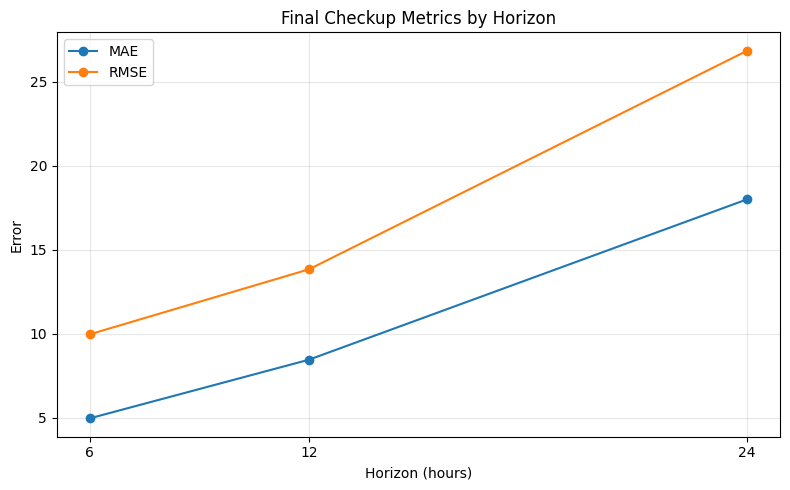

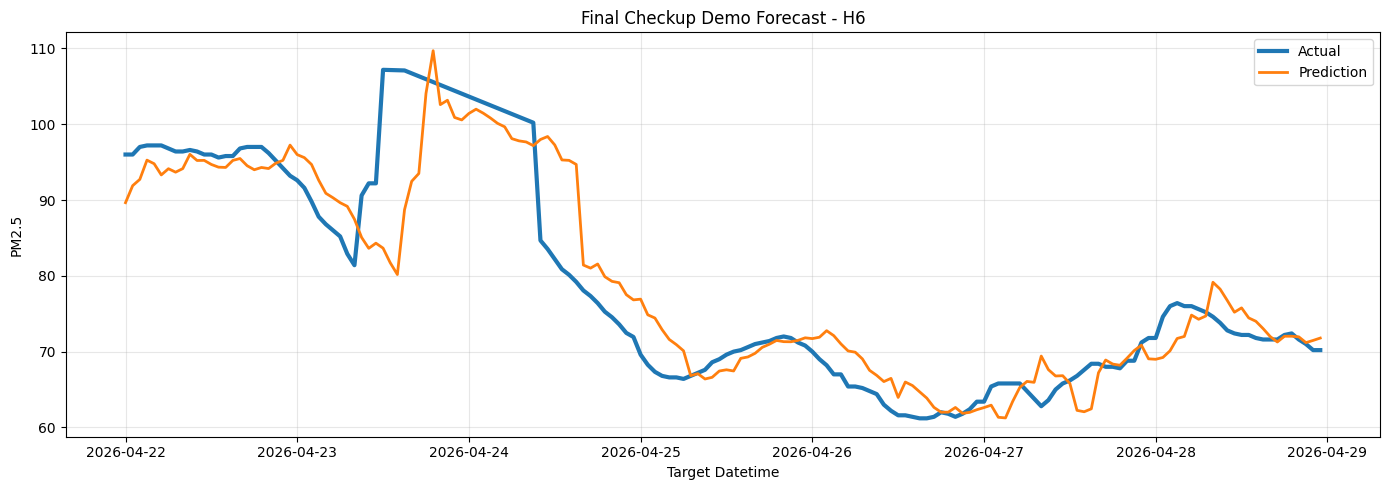

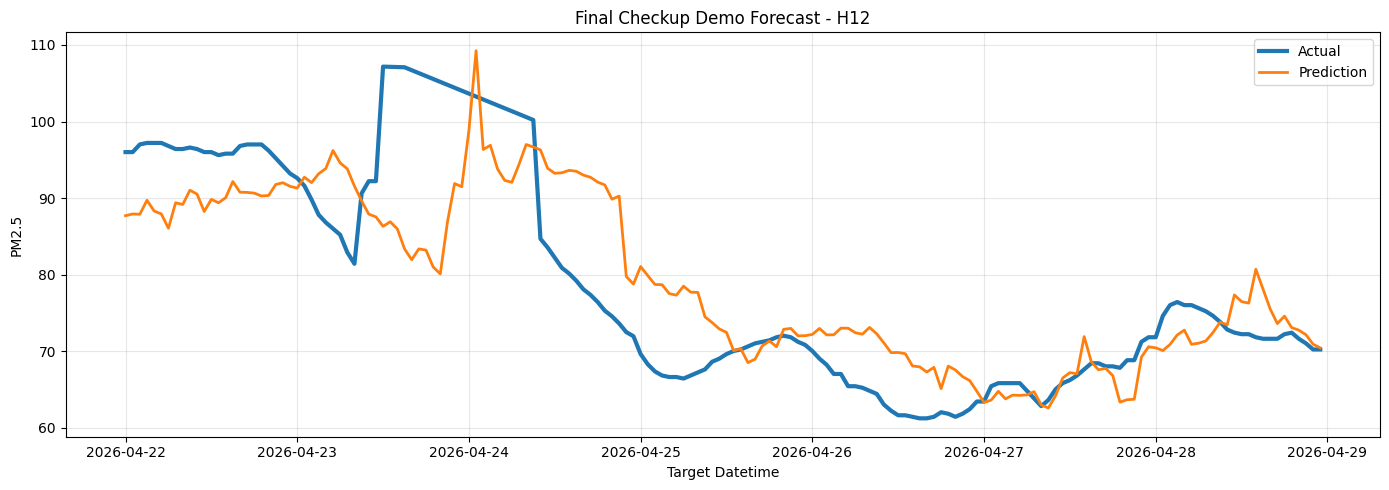

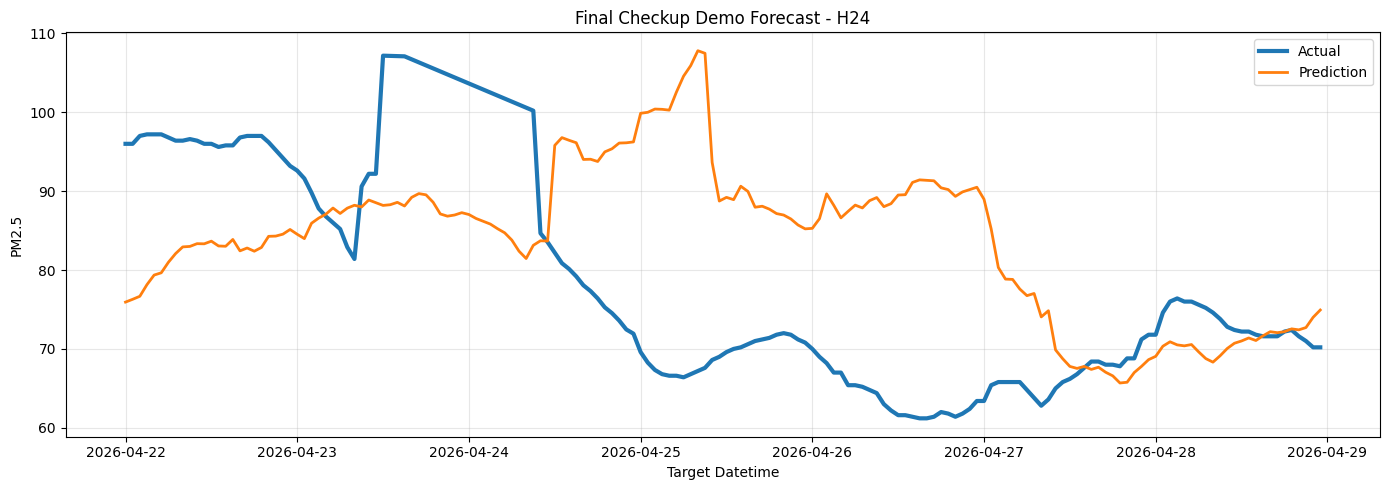

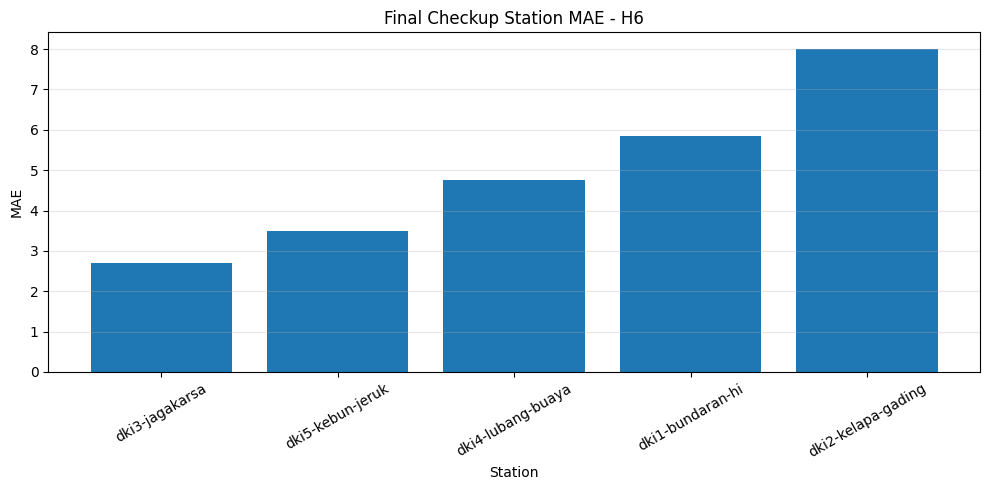

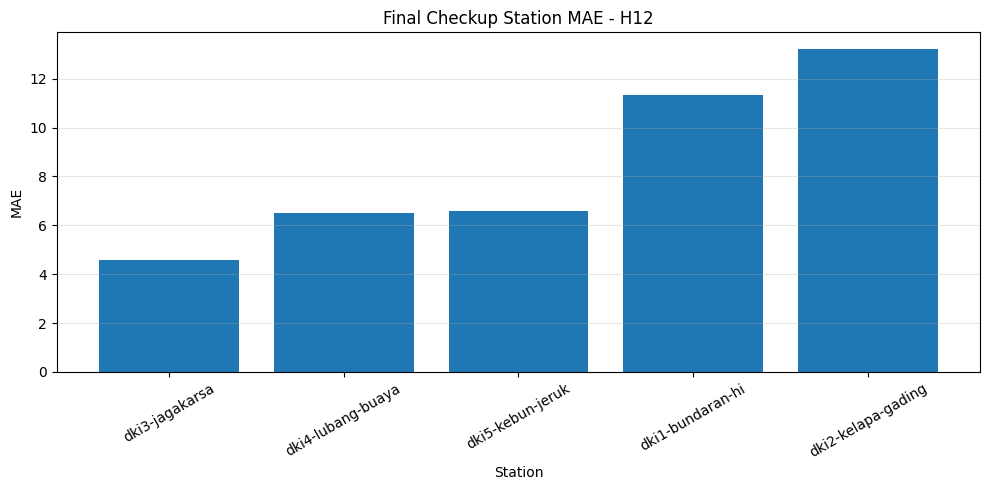

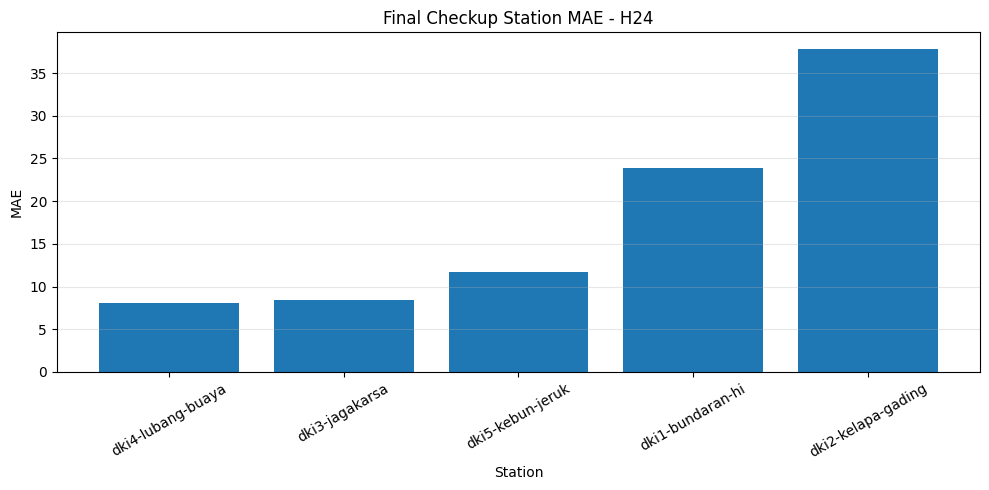

Charts saved in: /home/nafisnaufal1426/adit/Datathon/final_checkup/metrics


In [7]:
# =========================================================
# FINAL METRICS TABLES & CHARTS
# Output:
#   final_checkup/metrics/*.png
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FINAL_CHECKUP_DIR = Path("final_checkup")
PRED_DIR = FINAL_CHECKUP_DIR / "predictions"
METRIC_DIR = FINAL_CHECKUP_DIR / "metrics"

metrics_df = pd.read_csv(METRIC_DIR / "final_checkup_metrics_overall.csv")
station_metrics_df = pd.read_csv(METRIC_DIR / "final_checkup_metrics_by_station.csv")

# 1) overall MAE/RMSE by horizon
plt.figure(figsize=(8, 5))
plt.plot(metrics_df["horizon"], metrics_df["mae"], marker="o", label="MAE")
plt.plot(metrics_df["horizon"], metrics_df["rmse"], marker="o", label="RMSE")
plt.xticks(metrics_df["horizon"])
plt.xlabel("Horizon (hours)")
plt.ylabel("Error")
plt.title("Final Checkup Metrics by Horizon")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(METRIC_DIR / "final_checkup_metrics_by_horizon.png", dpi=200, bbox_inches="tight")
plt.show()

# 2) aggregated actual vs prediction per horizon
for horizon in [6, 12, 24]:
    pred_path = PRED_DIR / f"predictions_demo_h{horizon}.csv"
    pred_df = pd.read_csv(pred_path, low_memory=False)
    pred_df["target_datetime"] = pd.to_datetime(pred_df["target_datetime"], errors="coerce")

    agg = (
        pred_df.groupby("target_datetime", as_index=False)
        .agg(
            actual_target=("actual_target", "mean"),
            prediction=("prediction", "mean")
        )
        .sort_values("target_datetime")
    )

    plt.figure(figsize=(14, 5))
    plt.plot(agg["target_datetime"], agg["actual_target"], label="Actual", linewidth=3)
    plt.plot(agg["target_datetime"], agg["prediction"], label="Prediction", linewidth=2)
    plt.xlabel("Target Datetime")
    plt.ylabel("PM2.5")
    plt.title(f"Final Checkup Demo Forecast - H{horizon}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(METRIC_DIR / f"final_checkup_forecast_line_h{horizon}.png", dpi=200, bbox_inches="tight")
    plt.show()

# 3) bar chart MAE by station per horizon
for horizon in [6, 12, 24]:
    sub = station_metrics_df[station_metrics_df["horizon"] == horizon].copy()
    sub = sub.sort_values("mae")

    plt.figure(figsize=(10, 5))
    plt.bar(sub["station_slug"], sub["mae"])
    plt.xticks(rotation=30)
    plt.xlabel("Station")
    plt.ylabel("MAE")
    plt.title(f"Final Checkup Station MAE - H{horizon}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(METRIC_DIR / f"final_checkup_station_mae_h{horizon}.png", dpi=200, bbox_inches="tight")
    plt.show()

print("Charts saved in:", METRIC_DIR.resolve())

## Menjelaskan Prediksi Demo dengan SHAP dan JSON

Cell ini menjalankan tahap explainability untuk model final checkup menggunakan SHAP.

Input yang digunakan adalah:

| Input | Folder |
|---|---|
| Dataset fitur demo full | `final_checkup/features/` |
| Model final checkup | `final_checkup/models/` |
| Prediksi demo | `final_checkup/predictions/` |

Model yang dijelaskan adalah:

```text
final_checkup/models/final_checkup_lgbm_h6.pkl
final_checkup/models/final_checkup_lgbm_h12.pkl
final_checkup/models/final_checkup_lgbm_h24.pkl
```

### Proses SHAP

Untuk setiap horizon, cell ini melakukan:

1. Membaca dataset fitur.
2. Membaca model `.pkl`.
3. Menyiapkan fitur dengan one-hot encoding.
4. Mengambil baris demo berdasarkan target datetime.
5. Menghitung SHAP values.
6. Membuat SHAP global summary plot.
7. Menyimpan feature importance SHAP.
8. Membuat JSON prediksi dengan top SHAP features.

### Output SHAP

Output SHAP yang disimpan adalah:

```text
final_checkup/shap/final_checkup_shap_importance_h6.csv
final_checkup/shap/final_checkup_shap_importance_h12.csv
final_checkup/shap/final_checkup_shap_importance_h24.csv

final_checkup/shap/final_checkup_shap_global_h6.png
final_checkup/shap/final_checkup_shap_global_h12.png
final_checkup/shap/final_checkup_shap_global_h24.png
```

File `shap_importance` berisi ranking fitur berdasarkan `mean_abs_shap`. Semakin besar nilai `mean_abs_shap`, semakin besar pengaruh rata-rata fitur terhadap prediksi model.

### Output JSON

Cell ini juga menyimpan JSON prediksi dengan informasi SHAP:

```text
final_checkup/json/final_checkup_predictions_with_shap_h6.json
final_checkup/json/final_checkup_predictions_with_shap_h12.json
final_checkup/json/final_checkup_predictions_with_shap_h24.json
final_checkup/json/final_checkup_predictions_with_shap_all_horizons.json
```

Selain JSON, notebook juga menyimpan versi CSV ringkas per horizon:

```text
final_checkup/json/final_checkup_predictions_with_shap_h6.csv
final_checkup/json/final_checkup_predictions_with_shap_h12.csv
final_checkup/json/final_checkup_predictions_with_shap_h24.csv
```

JSON ini penting karena menjadi jembatan antara hasil prediksi model dan prompt package LLM. Di dalamnya terdapat prediksi, aktual, error, context features, dan top SHAP contributors.


===== FINAL CHECKUP SHAP H6 =====


/tmp/ipykernel_279797/2439768362.py:234: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


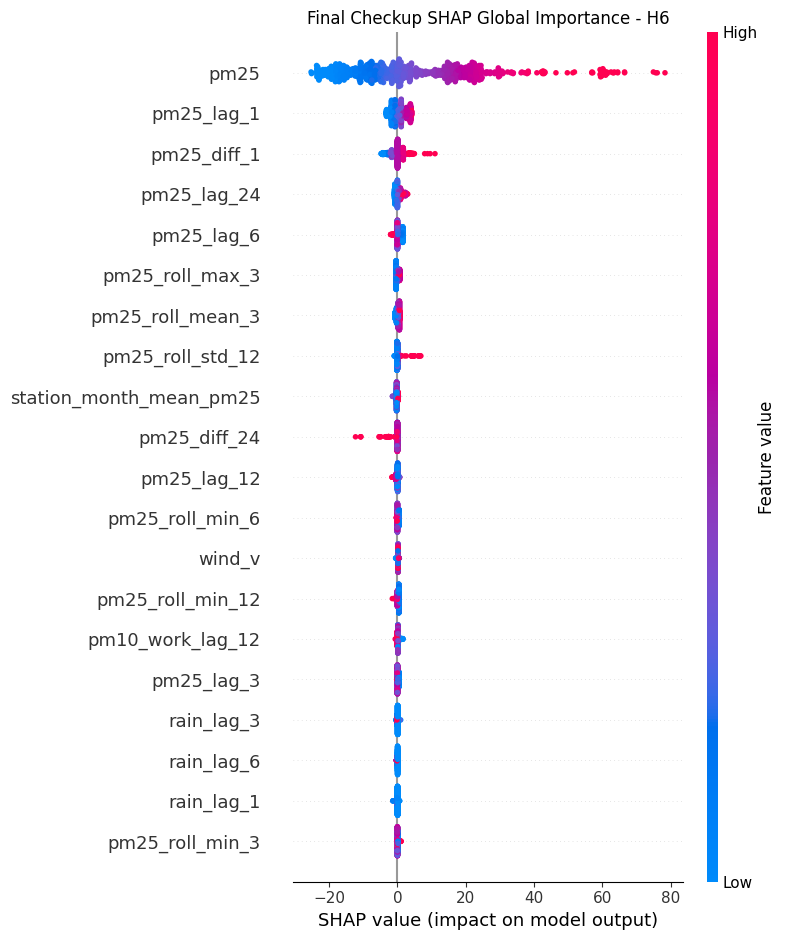

[SAVED] final_checkup/shap/final_checkup_shap_importance_h6.csv
[SAVED] final_checkup/json/final_checkup_predictions_with_shap_h6.json

===== FINAL CHECKUP SHAP H12 =====


/tmp/ipykernel_279797/2439768362.py:234: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


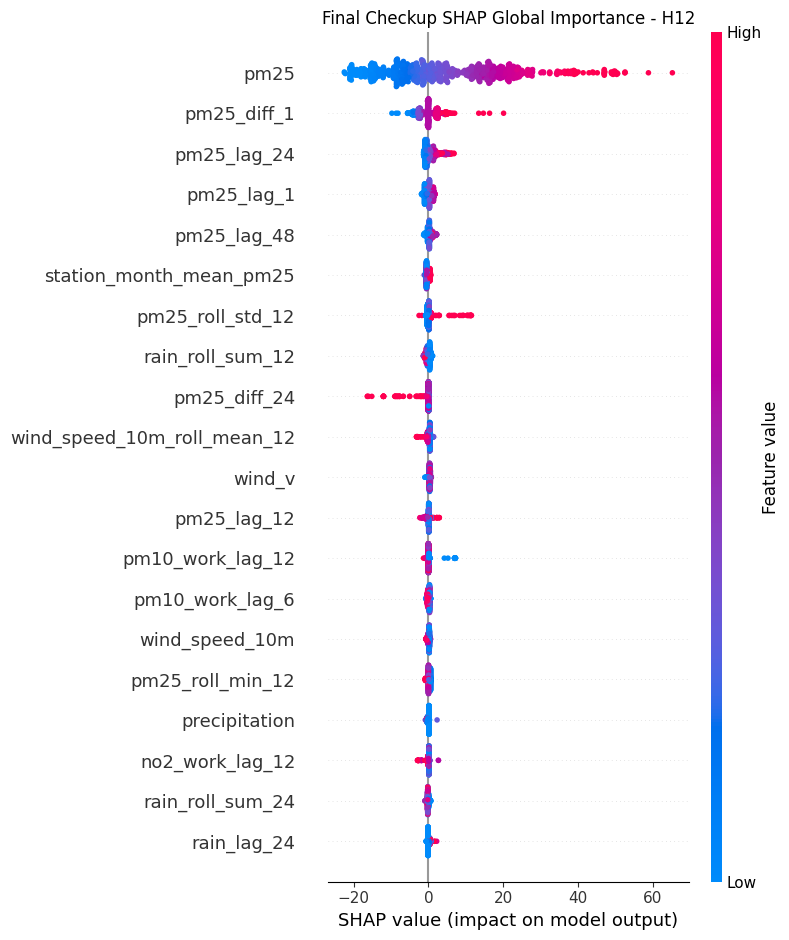

[SAVED] final_checkup/shap/final_checkup_shap_importance_h12.csv
[SAVED] final_checkup/json/final_checkup_predictions_with_shap_h12.json

===== FINAL CHECKUP SHAP H24 =====


/tmp/ipykernel_279797/2439768362.py:234: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


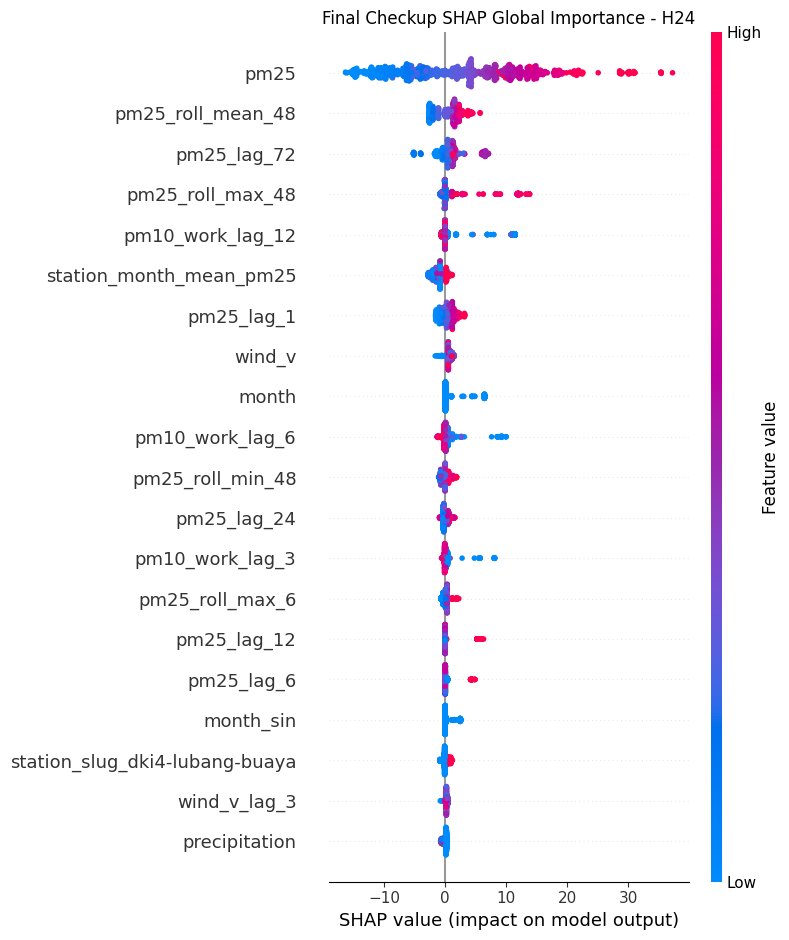

[SAVED] final_checkup/shap/final_checkup_shap_importance_h24.csv
[SAVED] final_checkup/json/final_checkup_predictions_with_shap_h24.json

[SAVED] final_checkup/json/final_checkup_predictions_with_shap_all_horizons.json
SHAP dir: /home/nafisnaufal1426/adit/Datathon/final_checkup/shap
JSON dir: /home/nafisnaufal1426/adit/Datathon/final_checkup/json


In [8]:
# =========================================================
# FINAL CHECKUP SHAP + JSON
# Pakai model final_checkup_lgbm_h6/h12/h24.pkl
# Output:
#   final_checkup/shap/final_checkup_shap_importance_h6.csv
#   final_checkup/shap/final_checkup_shap_importance_h12.csv
#   final_checkup/shap/final_checkup_shap_importance_h24.csv
#   final_checkup/shap/final_checkup_shap_global_h6.png
#   final_checkup/shap/final_checkup_shap_global_h12.png
#   final_checkup/shap/final_checkup_shap_global_h24.png
#   final_checkup/json/final_checkup_predictions_with_shap_h6.json
#   final_checkup/json/final_checkup_predictions_with_shap_h12.json
#   final_checkup/json/final_checkup_predictions_with_shap_h24.json
#   final_checkup/json/final_checkup_predictions_with_shap_all_horizons.json
# =========================================================

import os
import json
import random
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# -----------------------------
# SEED
# -----------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# -----------------------------
# PATHS
# -----------------------------
FINAL_CHECKUP_DIR = Path("final_checkup")
FEATURE_DIR = FINAL_CHECKUP_DIR / "features"
MODEL_DIR = FINAL_CHECKUP_DIR / "models"
SHAP_DIR = FINAL_CHECKUP_DIR / "shap"
JSON_DIR = FINAL_CHECKUP_DIR / "json"

SHAP_DIR.mkdir(exist_ok=True)
JSON_DIR.mkdir(exist_ok=True)

DATASET_PATHS = {
    6: FEATURE_DIR / "dataset_h6_demo_full.csv",
    12: FEATURE_DIR / "dataset_h12_demo_full.csv",
    24: FEATURE_DIR / "dataset_h24_demo_full.csv",
}

MODEL_PATHS = {
    6: MODEL_DIR / "final_checkup_lgbm_h6.pkl",
    12: MODEL_DIR / "final_checkup_lgbm_h12.pkl",
    24: MODEL_DIR / "final_checkup_lgbm_h24.pkl",
}

DEMO_TARGET_START = pd.Timestamp("2026-04-22 00:00:00")
DEMO_TARGET_END   = pd.Timestamp("2026-04-28 23:00:00")

TOP_SHAP_PER_ROW = 8
GLOBAL_MAX_DISPLAY = 20

# -----------------------------
# HELPERS
# -----------------------------
def load_dataset(path):
    df = pd.read_csv(path, low_memory=False)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    if "target_datetime" in df.columns:
        df["target_datetime"] = pd.to_datetime(df["target_datetime"], errors="coerce")

    sort_cols = [c for c in ["datetime", "station_slug"] if c in df.columns]
    if sort_cols:
        df = df.sort_values(sort_cols, kind="mergesort").reset_index(drop=True)
    elif "datetime" in df.columns:
        df = df.sort_values(["datetime"], kind="mergesort").reset_index(drop=True)

    return df

def prepare_xy_onehot(df, target_col):
    exclude_cols = {
        target_col,
        "datetime",
        "date",
        "target_datetime",
        "station_name",
        "lokasi",
        "season_simple",
    }
    exclude_cols = {c for c in exclude_cols if c in df.columns}

    X = df[[c for c in df.columns if c not in exclude_cols]].copy()
    y = df[target_col].copy()

    obj_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    X = pd.get_dummies(X, columns=obj_cols, dummy_na=False)

    return X, y

def safe_python_value(v):
    if pd.isna(v):
        return None
    if isinstance(v, bool):
        return bool(v)
    if isinstance(v, np.bool_):
        return bool(v)
    if isinstance(v, np.integer):
        return int(v)
    if isinstance(v, np.floating):
        return float(v)
    if isinstance(v, pd.Timestamp):
        return v.isoformat()
    return v

def sanitize_for_json(obj):
    if isinstance(obj, dict):
        return {str(k): sanitize_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [sanitize_for_json(v) for v in obj]
    else:
        return safe_python_value(obj)

def format_feature_name(feature_name):
    if str(feature_name).startswith("station_slug_"):
        slug = str(feature_name).replace("station_slug_", "")
        return f"station_slug={slug}"
    return str(feature_name)

def build_context_features(row_dict):
    preferred = [
        "pm25",
        "hour_num", "dayofweek", "month", "day",
        "is_weekend", "is_rush_morning", "is_rush_evening", "is_workhour",
        "season_dry_flag", "has_rain",
        "temperature_2m", "relative_humidity_2m", "rain",
        "surface_pressure", "wind_speed_10m", "wind_u", "wind_v",
        "pm25_lag_1", "pm25_lag_3", "pm25_lag_6", "pm25_lag_12", "pm25_lag_24",
        "pm25_roll_mean_3", "pm25_roll_mean_6", "pm25_roll_mean_12", "pm25_roll_mean_24",
        "station_hour_mean_pm25", "station_month_mean_pm25",
    ]
    context = {}
    for k in preferred:
        if k in row_dict:
            context[k] = safe_python_value(row_dict[k])
    return context

def get_top_shap_items(feature_names, feature_values, shap_values_row, top_k=8):
    items = []
    for f, val, sv in zip(feature_names, feature_values, shap_values_row):
        items.append({
            "feature": format_feature_name(f),
            "feature_value": safe_python_value(val),
            "shap_value": float(sv),
            "abs_shap_value": float(abs(sv)),
        })

    top_abs = sorted(items, key=lambda x: x["abs_shap_value"], reverse=True)[:top_k]
    top_pos = [x for x in items if x["shap_value"] > 0]
    top_pos = sorted(top_pos, key=lambda x: x["shap_value"], reverse=True)[:top_k]
    top_neg = [x for x in items if x["shap_value"] < 0]
    top_neg = sorted(top_neg, key=lambda x: x["shap_value"])[:top_k]

    def strip_abs(lst):
        return [
            {
                "feature": x["feature"],
                "feature_value": x["feature_value"],
                "shap_value": x["shap_value"],
            }
            for x in lst
        ]

    return strip_abs(top_abs), strip_abs(top_pos), strip_abs(top_neg)

all_json = {}

for horizon in [6, 12, 24]:
    print(f"\n===== FINAL CHECKUP SHAP H{horizon} =====")

    ds_path = DATASET_PATHS[horizon]
    model_path = MODEL_PATHS[horizon]
    target_col = f"target_pm25_t_plus_{horizon}"

    df_h = load_dataset(ds_path)

    test_df = df_h[
        (df_h["target_datetime"] >= DEMO_TARGET_START) &
        (df_h["target_datetime"] <= DEMO_TARGET_END)
    ].copy().reset_index(drop=True)

    if len(test_df) == 0:
        print(f"[SKIP] test_df kosong untuk h{horizon}")
        continue

    X_test, y_test = prepare_xy_onehot(test_df, target_col)
    X_test = X_test.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)

    with open(model_path, "rb") as f:
        model = pickle.load(f)

    # samakan feature test dengan feature model
    if hasattr(model, "booster_"):
        model_features = model.booster_.feature_name()
    else:
        model_features = list(X_test.columns)

    X_test = X_test.reindex(columns=model_features, fill_value=0)

    pred_test = model.predict(X_test)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # -----------------------------
    # GLOBAL SHAP IMPORTANCE
    # -----------------------------
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)

    shap_importance_csv = SHAP_DIR / f"final_checkup_shap_importance_h{horizon}.csv"
    shap_importance_df.to_csv(shap_importance_csv, index=False)

    plt.figure()
    shap.summary_plot(
        shap_values,
        X_test,
        show=False,
        max_display=GLOBAL_MAX_DISPLAY
    )
    plt.title(f"Final Checkup SHAP Global Importance - H{horizon}")
    plt.tight_layout()
    plt.savefig(SHAP_DIR / f"final_checkup_shap_global_h{horizon}.png", dpi=200, bbox_inches="tight")
    plt.show()

    # -----------------------------
    # JSON PER ROW
    # -----------------------------
    json_records = []
    for i in range(len(test_df)):
        row_meta = test_df.iloc[i].to_dict()
        row_x = X_test.iloc[i]
        row_shap = shap_values[i]

        top_abs, top_pos, top_neg = get_top_shap_items(
            feature_names=X_test.columns.tolist(),
            feature_values=row_x.values.tolist(),
            shap_values_row=row_shap,
            top_k=TOP_SHAP_PER_ROW
        )

        rec = {
            "horizon": horizon,
            "datetime": safe_python_value(row_meta.get("datetime")),
            "target_datetime": safe_python_value(row_meta.get("target_datetime")),
            "station_slug": safe_python_value(row_meta.get("station_slug")) if "station_slug" in test_df.columns else None,
            "station_id": safe_python_value(row_meta.get("station_id")) if "station_id" in test_df.columns else None,
            "station_name": safe_python_value(row_meta.get("station_name")) if "station_name" in test_df.columns else None,
            "current_pm25": safe_python_value(row_meta.get("pm25")) if "pm25" in test_df.columns else None,
            "actual_target": safe_python_value(y_test.iloc[i]),
            "prediction": safe_python_value(pred_test[i]),
            "absolute_error": safe_python_value(abs(y_test.iloc[i] - pred_test[i])),
            "context_features": build_context_features(row_meta),
            "top_shap_features": top_abs,
            "top_positive_contributors": top_pos,
            "top_negative_contributors": top_neg,
        }
        json_records.append(rec)

    horizon_json = {
        "horizon": horizon,
        "target_column": target_col,
        "date_range": {
            "target_start": safe_python_value(DEMO_TARGET_START),
            "target_end": safe_python_value(DEMO_TARGET_END),
        },
        "n_rows": len(json_records),
        "global_top_features": shap_importance_df.head(15).to_dict(orient="records"),
        "predictions": json_records,
    }

    json_path = JSON_DIR / f"final_checkup_predictions_with_shap_h{horizon}.json"
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(sanitize_for_json(horizon_json), f, ensure_ascii=False, indent=2)

    # csv ringkas juga
    flat_rows = []
    for r in json_records:
        flat_rows.append({
            "horizon": r["horizon"],
            "datetime": r["datetime"],
            "target_datetime": r["target_datetime"],
            "station_slug": r["station_slug"],
            "station_id": r["station_id"],
            "station_name": r["station_name"],
            "current_pm25": r["current_pm25"],
            "actual_target": r["actual_target"],
            "prediction": r["prediction"],
            "absolute_error": r["absolute_error"],
            "top_shap_features": json.dumps(r["top_shap_features"], ensure_ascii=False),
        })
    pd.DataFrame(flat_rows).to_csv(
        JSON_DIR / f"final_checkup_predictions_with_shap_h{horizon}.csv",
        index=False
    )

    all_json[f"h{horizon}"] = horizon_json

    print("[SAVED]", shap_importance_csv)
    print("[SAVED]", json_path)

# gabungan semua horizon
all_json_path = JSON_DIR / "final_checkup_predictions_with_shap_all_horizons.json"
with open(all_json_path, "w", encoding="utf-8") as f:
    json.dump(sanitize_for_json(all_json), f, ensure_ascii=False, indent=2)

print("\n[SAVED]", all_json_path)
print("SHAP dir:", SHAP_DIR.resolve())
print("JSON dir:", JSON_DIR.resolve())

## Membentuk Prompt Package Final Checkup untuk LLM AirSafe

Cell ini mengubah prediksi multi-horizon yang sudah dilengkapi SHAP menjadi prompt package untuk LLM rekomendasi AirSafe.

Input utama yang digunakan adalah:

```text
final_checkup/json/final_checkup_predictions_with_shap_all_horizons.json
airsafe_recommendation_system.txt
airsafe_recommendation_user.txt
```

### Proses yang Dilakukan

Cell ini melakukan beberapa tahap:

1. Membaca system prompt template.
2. Membaca user prompt template.
3. Membaca JSON prediksi semua horizon.
4. Mengubah prediksi H6, H12, dan H24 menjadi dataframe.
5. Menggabungkan prediksi berdasarkan `datetime` dan `station_slug`.
6. Menggabungkan top factors dari SHAP.
7. Menentukan risk level dari prediksi PM2.5.
8. Membentuk prompt package per baris.
9. Menyimpan hasil ke CSV, JSON, dan JSONL.

### Risk Level

Risk level diturunkan dari prediksi PM2.5 H6, H12, dan H24. Secara konsep, semakin tinggi prediksi PM2.5, semakin tinggi level risiko operasional yang diberikan.

Contoh risk level pada output adalah:

```text
Bahaya
```

Pada contoh package, prediksi PM2.5 adalah:

| Horizon | Prediksi PM2.5 |
|---:|---:|
| H6 | 87.9876 |
| H12 | 84.4242 |
| H24 | 80.7846 |

Karena nilai prediksi cukup tinggi, sistem memberikan risk level `Bahaya`.

### Output Prompt Package

File yang disimpan adalah:

```text
final_checkup/prompt_packages/final_checkup_prompt_input.csv
final_checkup/prompt_packages/final_checkup_prompt_packages.json
final_checkup/prompt_packages/final_checkup_prompt_packages.jsonl
```

Jumlah prompt package yang terbentuk adalah:

```text
750
```

Prompt package berisi informasi seperti:

| Komponen | Isi |
|---|---|
| `school_id` | ID sekolah atau fallback dari `station_slug` |
| `school_name` | Nama sekolah atau fallback dari nama stasiun |
| `district` | Wilayah jika tersedia |
| `station_slug` | Identitas stasiun |
| `datetime` | Waktu prediksi |
| `risk_level` | Level risiko |
| `pm25_6h` | Prediksi PM2.5 6 jam |
| `pm25_12h` | Prediksi PM2.5 12 jam |
| `pm25_24h` | Prediksi PM2.5 24 jam |
| `actual_6h`, `actual_12h`, `actual_24h` | Nilai aktual untuk evaluasi demo |
| `top_factors` | Faktor penting dari SHAP |
| `system_prompt` | Instruksi sistem untuk LLM |
| `user_prompt` | Prompt user yang sudah diisi data prediksi |

Cell ini menjadi tahap akhir pipeline karena hasil forecasting dan SHAP sudah dikemas menjadi input siap pakai untuk sistem rekomendasi berbasis LLM.

In [9]:
# =========================================================
# FINAL CHECKUP -> PROMPT PACKAGE FOR LLM
# Input:
#   final_checkup/json/final_checkup_predictions_with_shap_all_horizons.json
#   /mnt/data/airsafe_recommendation_system.txt
#   /mnt/data/airsafe_recommendation_user.txt
#
# Output:
#   final_checkup/prompt_packages/final_checkup_prompt_input.csv
#   final_checkup/prompt_packages/final_checkup_prompt_packages.json
#   final_checkup/prompt_packages/final_checkup_prompt_packages.jsonl
# =========================================================

import json
from pathlib import Path
import pandas as pd
import numpy as np

# -----------------------------
# PATHS
# -----------------------------
FINAL_CHECKUP_DIR = Path("final_checkup")
JSON_DIR = FINAL_CHECKUP_DIR / "json"
PROMPT_DIR = FINAL_CHECKUP_DIR / "prompt_packages"
PROMPT_DIR.mkdir(exist_ok=True)

SYSTEM_PROMPT_PATH = "airsafe_recommendation_system.txt"
USER_PROMPT_PATH = "airsafe_recommendation_user.txt"
PRED_JSON_PATH = JSON_DIR / "final_checkup_predictions_with_shap_all_horizons.json"

# OPTIONAL:
# kalau nanti kamu punya mapping station -> school
# kolom minimal yang didukung:
# station_slug, school_id, school_name, district
STATION_META_PATH = None   # contoh: "station_school_meta.csv"

# -----------------------------
# LOAD PROMPTS
# -----------------------------
with open(SYSTEM_PROMPT_PATH, "r", encoding="utf-8") as f:
    SYSTEM_PROMPT_TEMPLATE = f.read()

with open(USER_PROMPT_PATH, "r", encoding="utf-8") as f:
    USER_PROMPT_TEMPLATE = f.read()

with open(PRED_JSON_PATH, "r", encoding="utf-8") as f:
    pred_all = json.load(f)

# -----------------------------
# HELPERS
# -----------------------------
def safe_python_value(v):
    if v is None:
        return None
    if isinstance(v, bool):
        return bool(v)
    if isinstance(v, (np.bool_,)):
        return bool(v)
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v)
    if isinstance(v, pd.Timestamp):
        return v.isoformat()
    return v

def sanitize_for_json(obj):
    if isinstance(obj, dict):
        return {str(k): sanitize_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [sanitize_for_json(v) for v in obj]
    else:
        return safe_python_value(obj)

def horizon_json_to_df(horizon_key, horizon_num):
    preds = pred_all[horizon_key]["predictions"]
    rows = []

    for r in preds:
        top_feats = r.get("top_shap_features", [])
        feat_names = []
        for item in top_feats[:3]:
            feat = item.get("feature")
            if feat is not None:
                feat_names.append(str(feat))

        rows.append({
            "datetime": r.get("datetime"),
            "station_slug": r.get("station_slug"),
            "station_id": r.get("station_id"),
            "station_name": r.get("station_name"),
            f"pm25_{horizon_num}h": r.get("prediction"),
            f"actual_{horizon_num}h": r.get("actual_target"),
            f"top_factors_{horizon_num}h": ", ".join(feat_names) if feat_names else "-",
        })

    df = pd.DataFrame(rows)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    return df

def combine_top_factors(row):
    factors = []
    for c in ["top_factors_6h", "top_factors_12h", "top_factors_24h"]:
        val = row.get(c, None)
        if pd.notna(val) and str(val).strip() not in {"", "-"}:
            parts = [x.strip() for x in str(val).split(",")]
            factors.extend(parts[:2])  # ambil 2 teratas per horizon

    seen = set()
    uniq = []
    for f in factors:
        if f and f not in seen:
            seen.add(f)
            uniq.append(f)

    return ", ".join(uniq[:6]) if uniq else "-"

# ---------------------------------------
# RISK LEVEL
# sesuaikan threshold ini bila perlu
# ---------------------------------------
def derive_risk_level(pm25_6h, pm25_12h, pm25_24h):
    vals = [pm25_6h, pm25_12h, pm25_24h]
    vals = [v for v in vals if pd.notna(v)]

    if len(vals) == 0:
        return "Waspada"

    max_pm25 = max(vals)

    # threshold sederhana, silakan sesuaikan kalau kamu punya rule resmi
    if max_pm25 <= 15:
        return "Aman"
    elif max_pm25 <= 35:
        return "Waspada"
    elif max_pm25 <= 55:
        return "Batasi"
    else:
        return "Bahaya"

# -----------------------------
# BUILD MERGED TABLE
# -----------------------------
df6 = horizon_json_to_df("h6", 6)
df12 = horizon_json_to_df("h12", 12)
df24 = horizon_json_to_df("h24", 24)

merge_keys = ["datetime", "station_slug", "station_id", "station_name"]

merged = df6.merge(df12, on=merge_keys, how="inner")
merged = merged.merge(df24, on=merge_keys, how="inner")

# merge metadata school kalau ada
if STATION_META_PATH is not None:
    station_meta = pd.read_csv(STATION_META_PATH)
    merged = merged.merge(station_meta, on="station_slug", how="left")
else:
    merged["school_id"] = merged["station_slug"]
    merged["school_name"] = merged["station_name"].fillna(merged["station_slug"])
    merged["district"] = None

merged["risk_level"] = merged.apply(
    lambda r: derive_risk_level(r["pm25_6h"], r["pm25_12h"], r["pm25_24h"]),
    axis=1
)

merged["top_factors"] = merged.apply(combine_top_factors, axis=1)

# save input tabular
input_csv_path = PROMPT_DIR / "final_checkup_prompt_input.csv"
merged.to_csv(input_csv_path, index=False)

# -----------------------------
# BUILD PROMPT PACKAGES
# -----------------------------
prompt_records = []

for _, row in merged.iterrows():
    user_prompt_filled = USER_PROMPT_TEMPLATE.format(
        school_name=row.get("school_name"),
        district=row.get("district"),
        pm25_6h=row.get("pm25_6h"),
        pm25_12h=row.get("pm25_12h"),
        pm25_24h=row.get("pm25_24h"),
        risk_level=row.get("risk_level"),
        top_factors=row.get("top_factors"),
    )

    prompt_records.append({
        "school_id": safe_python_value(row.get("school_id")),
        "school_name": safe_python_value(row.get("school_name")),
        "district": safe_python_value(row.get("district")),
        "station_slug": safe_python_value(row.get("station_slug")),
        "station_id": safe_python_value(row.get("station_id")),
        "datetime": safe_python_value(row.get("datetime")),
        "risk_level": safe_python_value(row.get("risk_level")),
        "pm25_6h": safe_python_value(row.get("pm25_6h")),
        "pm25_12h": safe_python_value(row.get("pm25_12h")),
        "pm25_24h": safe_python_value(row.get("pm25_24h")),
        "actual_6h": safe_python_value(row.get("actual_6h")),
        "actual_12h": safe_python_value(row.get("actual_12h")),
        "actual_24h": safe_python_value(row.get("actual_24h")),
        "top_factors": safe_python_value(row.get("top_factors")),
        "system_prompt": SYSTEM_PROMPT_TEMPLATE,
        "user_prompt": user_prompt_filled,
    })

# save JSON
json_path = PROMPT_DIR / "final_checkup_prompt_packages.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(sanitize_for_json(prompt_records), f, ensure_ascii=False, indent=2)

# save JSONL
jsonl_path = PROMPT_DIR / "final_checkup_prompt_packages.jsonl"
with open(jsonl_path, "w", encoding="utf-8") as f:
    for rec in prompt_records:
        f.write(json.dumps(sanitize_for_json(rec), ensure_ascii=False) + "\n")

print("[SAVED]", input_csv_path)
print("[SAVED]", json_path)
print("[SAVED]", jsonl_path)

print("\nJumlah prompt package:", len(prompt_records))
print("\nContoh 1 package:")
print(json.dumps(sanitize_for_json(prompt_records[0]), ensure_ascii=False, indent=2)[:2500])

[SAVED] final_checkup/prompt_packages/final_checkup_prompt_input.csv
[SAVED] final_checkup/prompt_packages/final_checkup_prompt_packages.json
[SAVED] final_checkup/prompt_packages/final_checkup_prompt_packages.jsonl

Jumlah prompt package: 750

Contoh 1 package:
{
  "school_id": "dki1-bundaran-hi",
  "school_name": "DKI1 Bundaran HI",
  "district": null,
  "station_slug": "dki1-bundaran-hi",
  "station_id": 4,
  "datetime": "2026-04-21T18:00:00",
  "risk_level": "Bahaya",
  "pm25_6h": 87.98762672772284,
  "pm25_12h": 84.42419023537954,
  "pm25_24h": 80.78459499686706,
  "actual_6h": 96.0,
  "actual_12h": 102.0,
  "actual_24h": 104.0,
  "top_factors": "pm25, pm25_lag_1, rain_roll_sum_12, station_month_mean_pm25",
  "system_prompt": "You are AirSafe School, an AI assistant that writes operational air-quality recommendations for schools in Jakarta.\n\nYour task is to convert PM2.5 forecasts, risk level, and model explanation factors into clear Bahasa Indonesia recommendations for school p

# Kesimpulan Final Checkup

Notebook ini berhasil menjalankan pipeline final checkup secara end-to-end untuk periode demo `2026-04-22` sampai `2026-04-28`.

Tahap yang berhasil dilakukan meliputi:

1. Scraping data SPKU 5 stasiun.
2. Pengambilan data weather Open-Meteo.
3. Merge data demo dengan historical master.
4. Pembuatan ulang fitur H6, H12, dan H24.
5. Training ulang LightGBM dengan best params.
6. Evaluasi pada target demo.
7. Pembuatan grafik metrik dan forecast.
8. SHAP explainability.
9. JSON prediksi dengan top SHAP.
10. Prompt package untuk LLM AirSafe.

Ringkasan metrik final checkup:

| Horizon | Removed Group | MAE | RMSE |
|---:|---|---:|---:|
| H6 | `weather_roll` | 4.9588 | 9.9601 |
| H12 | `NONE` | 8.4480 | 13.8264 |
| H24 | `weather_roll` | 17.9948 | 26.8395 |

Hasil menunjukkan bahwa performa terbaik ada pada H6, sedangkan H24 menjadi horizon paling sulit. Hal ini wajar karena semakin jauh horizon prediksi, semakin besar ketidakpastian kondisi PM2.5.

Secara keseluruhan, notebook ini menunjukkan bahwa pipeline AirSafe sudah mampu mengalir dari data terbaru sampai ke prompt LLM. Artinya, sistem tidak hanya menghasilkan prediksi numerik, tetapi juga menyediakan penjelasan fitur dan input rekomendasi operasional.

# Struktur Folder dan File Output Notebook

Notebook ini menghasilkan satu folder utama:

```text
final_checkup/
```

Struktur output dapat diringkas sebagai berikut:

```text
project/
│
├── dataset_master_spku_weather.csv
├── airsafe_recommendation_system.txt
├── airsafe_recommendation_user.txt
│
├── outputs_phase2/
│   ├── best_params_h6.json
│   ├── best_params_h12.json
│   └── best_params_h24.json
│
└── final_checkup/
    │
    ├── raw_spku_20260422_20260428/
    │   ├── dki1-bundaran-hi_20260422_20260428.csv.gz
    │   ├── dki2-kelapa-gading_20260422_20260428.csv.gz
    │   ├── dki3-jagakarsa_20260422_20260428.csv.gz
    │   ├── dki4-lubang-buaya_20260422_20260428.csv.gz
    │   └── dki5-kebun-jeruk_20260422_20260428.csv.gz
    │
    ├── logs_spku_20260422_20260428/
    │   ├── dki1-bundaran-hi_20260422_20260428_log.csv
    │   ├── dki2-kelapa-gading_20260422_20260428_log.csv
    │   ├── dki3-jagakarsa_20260422_20260428_log.csv
    │   ├── dki4-lubang-buaya_20260422_20260428_log.csv
    │   └── dki5-kebun-jeruk_20260422_20260428_log.csv
    │
    ├── weather_raw/
    │   ├── weather_demo_2026-04-22_2026-04-28.csv
    │   └── weather_demo_2026-04-22_2026-04-28.parquet
    │
    ├── master/
    │   ├── spku_demo_5stations_2026-04-22_2026-04-28.csv
    │   ├── spku_demo_5stations_2026-04-22_2026-04-28.parquet
    │   ├── dataset_master_spku_weather_demo_only.csv
    │   ├── dataset_master_spku_weather_demo_only.parquet
    │   ├── dataset_master_spku_weather_full_until_2026-04-28.csv
    │   └── dataset_master_spku_weather_full_until_2026-04-28.parquet
    │
    ├── features/
    │   ├── dataset_h6_demo_full.csv
    │   ├── dataset_h12_demo_full.csv
    │   └── dataset_h24_demo_full.csv
    │
    ├── models/
    │   ├── final_checkup_lgbm_h6.pkl
    │   ├── final_checkup_lgbm_h12.pkl
    │   └── final_checkup_lgbm_h24.pkl
    │
    ├── predictions/
    │   ├── predictions_demo_h6.csv
    │   ├── predictions_demo_h12.csv
    │   └── predictions_demo_h24.csv
    │
    ├── metrics/
    │   ├── final_checkup_metrics_overall.csv
    │   ├── final_checkup_metrics_by_station.csv
    │   ├── final_checkup_metrics_by_horizon.png
    │   ├── final_checkup_forecast_line_h6.png
    │   ├── final_checkup_forecast_line_h12.png
    │   ├── final_checkup_forecast_line_h24.png
    │   ├── final_checkup_station_mae_h6.png
    │   ├── final_checkup_station_mae_h12.png
    │   └── final_checkup_station_mae_h24.png
    │
    ├── shap/
    │   ├── final_checkup_shap_importance_h6.csv
    │   ├── final_checkup_shap_importance_h12.csv
    │   ├── final_checkup_shap_importance_h24.csv
    │   ├── final_checkup_shap_global_h6.png
    │   ├── final_checkup_shap_global_h12.png
    │   └── final_checkup_shap_global_h24.png
    │
    ├── json/
    │   ├── final_checkup_predictions_with_shap_h6.json
    │   ├── final_checkup_predictions_with_shap_h6.csv
    │   ├── final_checkup_predictions_with_shap_h12.json
    │   ├── final_checkup_predictions_with_shap_h12.csv
    │   ├── final_checkup_predictions_with_shap_h24.json
    │   ├── final_checkup_predictions_with_shap_h24.csv
    │   └── final_checkup_predictions_with_shap_all_horizons.json
    │
    └── prompt_packages/
        ├── final_checkup_prompt_input.csv
        ├── final_checkup_prompt_packages.json
        └── final_checkup_prompt_packages.jsonl
```

## Penjelasan Folder Output

| Folder | Fungsi |
|---|---|
| `raw_spku_20260422_20260428/` | Menyimpan hasil scraping SPKU mentah per stasiun |
| `logs_spku_20260422_20260428/` | Menyimpan log scraping |
| `weather_raw/` | Menyimpan data cuaca demo dari Open-Meteo |
| `master/` | Menyimpan master SPKU demo, demo-only master, dan full master terbaru |
| `features/` | Menyimpan dataset fitur H6, H12, dan H24 |
| `models/` | Menyimpan model LightGBM final checkup |
| `predictions/` | Menyimpan prediksi periode demo |
| `metrics/` | Menyimpan metrik dan grafik evaluasi |
| `shap/` | Menyimpan SHAP importance dan SHAP global plot |
| `json/` | Menyimpan prediksi dengan top SHAP contributors |
| `prompt_packages/` | Menyimpan prompt package untuk LLM AirSafe |

## File Paling Penting

File yang paling penting dari notebook ini adalah:

```text
final_checkup/metrics/final_checkup_metrics_overall.csv
final_checkup/metrics/final_checkup_metrics_by_station.csv
final_checkup/predictions/predictions_demo_h6.csv
final_checkup/predictions/predictions_demo_h12.csv
final_checkup/predictions/predictions_demo_h24.csv
final_checkup/json/final_checkup_predictions_with_shap_all_horizons.json
final_checkup/prompt_packages/final_checkup_prompt_packages.jsonl
```

File-file tersebut dapat digunakan untuk laporan final, evaluasi model, analisis error, interpretasi SHAP, dan batch inference rekomendasi LLM.